# 04e: LSTM Models

## Objective
Train LSTM (Long Short-Term Memory) deep learning models for weekly bed occupancy forecasting with comprehensive feature selection.

## Data Source
- **Hospital:** ADVENTHEALTH ORLANDO
- **Date Range:** 2020-07-19 to 2024-04-21 (197 weeks)
- **Target Variable:** `bed_occupancy` (weekly average occupied beds)
- **Train/Test Split:** 157/40 weeks (80/20)

## Approach
1. Load feature-engineered data from notebook 03
2. Perform feature selection optimized for neural networks
3. Create sequences for LSTM training
4. Train multiple LSTM architectures
5. Evaluate and compare models

## Requirements
- Feature-engineered data from notebook 03 (`occupancy_with_features.csv` or `features_for_lstm.csv`)
- Target: `bed_occupancy`
- GPU recommended for faster training (10-50x speedup)


## GPU Acceleration (Recommended)

**This notebook benefits significantly from GPU acceleration for LSTM training!**

### GPU Benefits:
- **LSTM training:** GPU provides 10-50x speedup for deep learning
- Faster sequence processing and backpropagation
- Enables more epochs and hyperparameter tuning

### Performance:
- **GPU:** ~1-2 minutes total training time
- **CPU:** ~10-15 minutes (still works fine)

### Note:
If GPU is unavailable, CPU runtime is perfectly acceptable for this dataset size.


## Install Dependencies (if needed)

If packages are missing, install them here.


In [ ]:
# ============================================================================
# PROJECT CONFIGURATION & IMPORTS
# ============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import json
from datetime import datetime
warnings.filterwarnings('ignore')

# Setup paths - mount Google Drive if not already mounted (matching notebook 03)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive
    # Check if drive is already mounted
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        # Mount Google Drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    # Set up Google Drive paths
    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_occupancy_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, 'models')
        DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'visualizations', 'model_development')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local Colab paths only")

# Local Colab paths
PROJECT_ROOT = '/content/hospital_occupancy_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RAW = os.path.join(DATA_DIR, 'raw')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'visualizations', 'model_development')

for path in [DATA_RAW, DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Helper function to save files to both local and Google Drive
def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """
    Save file to both local and Google Drive (if available).

    Args:
        data: Data to save (DataFrame, dict, model, etc.)
        filename: Name of the file
        local_path: Local directory path
        drive_path: Google Drive directory path (optional)
        **kwargs: Additional arguments for save methods (e.g., index=False for to_csv)
    """
    # Save to local
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif isinstance(data, (dict, list)) and filename.endswith('.json'):
        import json
        with open(local_file, 'w') as f:
            json.dump(data, f, **kwargs)
    elif filename.endswith('.pkl'):
        import pickle
        with open(local_file, 'wb') as f:
            pickle.dump(data, f)
    elif hasattr(data, 'save'):
        data.save(local_file)
    else:
        # Fallback: try to write as text
        with open(local_file, 'w') as f:
            f.write(str(data))
    print(f"✓ Saved to local: {local_file}")

    # Save to Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif isinstance(data, (dict, list)) and filename.endswith('.json'):
                import json
                with open(drive_file, 'w') as f:
                    json.dump(data, f, **kwargs)
            elif filename.endswith('.pkl'):
                import pickle
                with open(drive_file, 'wb') as f:
                    pickle.dump(data, f)
            elif hasattr(data, 'save'):
                data.save(drive_file)
            else:
                with open(drive_file, 'w') as f:
                    f.write(str(data))
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")

# Helper function to save plots to both locations (matching notebook 02)
def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")

# Helper function to load file from multiple locations (matching notebook 03)
def load_file(filename, local_path, drive_path=None):
    """
    Load file from local or Google Drive (local priority).

    Returns:
        Loaded data or None if not found
    """
    # Try local first
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith('.csv'):
            return pd.read_csv(local_file, index_col=0, parse_dates=True)
        elif filename.endswith('.pkl'):
            import pickle
            with open(local_file, 'rb') as f:
                return pickle.load(f)
        elif filename.endswith('.json'):
            import json
            with open(local_file, 'r') as f:
                return json.load(f)
        elif filename.endswith('.h5'):
            from tensorflow import keras
            return keras.models.load_model(local_file)

    # Try Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith('.csv'):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=True)
                elif filename.endswith('.pkl'):
                    import pickle
                    with open(drive_file, 'rb') as f:
                        return pickle.load(f)
                elif filename.endswith('.json'):
                    import json
                    with open(drive_file, 'r') as f:
                        return json.load(f)
                elif filename.endswith('.h5'):
                    from tensorflow import keras
                    return keras.models.load_model(drive_file)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")

    return None



✓ Google Drive already mounted
✓ Google Drive paths configured: /content/drive/MyDrive/hospital_occupancy_forecasting


## Load Feature-Engineered Data

Load the feature-engineered data from notebook 03. We'll perform feature selection specifically optimized for LSTM neural networks.


In [ ]:
# ============================================================================
# LOAD FEATURE-ENGINEERED DATA
# ============================================================================
print("="*70)
print("LOADING FEATURE-ENGINEERED DATA")
print("="*70)

# Try loading LSTM-specific features first, then fallback to full features
data = load_file('features_for_lstm.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is None:
    # Fallback: load full feature-engineered data
    data = load_file('occupancy_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
    if data is not None:
        print("✓ Loaded full feature-engineered data (occupancy_with_features.csv)")
    else:
        print("❌ No feature-engineered data found!")
        print("   Please run notebook 03_feature_engineering.ipynb first")
        data = None

if data is not None:
    print(f"\n✓ Loaded data: {len(data)} weeks")
    print(f"  Date range: {data.index.min().date()} to {data.index.max().date()}")
    print(f"  Columns: {len(data.columns)}")
    print(f"  Target variable: {'bed_occupancy' if 'bed_occupancy' in data.columns else 'NOT FOUND'}")

    # Display available columns
    print(f"\n📋 Available columns ({len(data.columns)}):")
    for i, col in enumerate(data.columns[:20], 1):
        print(f"  {i:2d}. {col}")
    if len(data.columns) > 20:
        print(f"  ... and {len(data.columns) - 20} more columns")

    # Check for target variable
    if 'bed_occupancy' not in data.columns:
        print("\n⚠️  WARNING: 'bed_occupancy' not found in data!")
        print("   Available columns:", list(data.columns))
        target_col = None
    else:
        target_col = 'bed_occupancy'
        print(f"\n✓ Target variable found: {target_col}")
        print(f"  Statistics:")
        print(f"    Mean: {data[target_col].mean():.2f}")
        print(f"    Std: {data[target_col].std():.2f}")
        print(f"    Min: {data[target_col].min():.2f}")
        print(f"    Max: {data[target_col].max():.2f}")
else:
    target_col = None
    print("\n❌ Cannot proceed without data")

LOADING FEATURE-ENGINEERED DATA

✓ Loaded data: 197 weeks
  Date range: 2020-07-19 to 2024-04-21
  Columns: 14
  Target variable: bed_occupancy

📋 Available columns (14):
   1. bed_occupancy
   2. quarter_sin
   3. quarter_cos
   4. day_of_year_sin
   5. day_of_year_cos
   6. bed_occupancy_lag_1
   7. bed_occupancy_lag_3
   8. bed_occupancy_lag_4
   9. bed_occupancy_lag_52
  10. rolling_mean_4
  11. rolling_std_4
  12. ili_lag_1
  13. ili_lag_4
  14. bed_occupancy_lag_1.1

✓ Target variable found: bed_occupancy
  Statistics:
    Mean: 2254.37
    Std: 136.47
    Min: 1882.00
    Max: 2510.70


## Feature Selection for LSTM

Perform feature selection optimized for neural networks. Based on notebook 03 findings:
- **Priority features**: Lag features (1, 3, 4, 52), rolling statistics, external features (ili, flu_activity_level, temp_avg)
- **Neural network considerations**: Can handle higher correlation (0.95 threshold), benefit from cyclical encoding
- **Feature importance**: Use correlation and mutual information for selection


In [ ]:
# ============================================================================
# IMPROVED FEATURE SELECTION FOR LSTM (More Aggressive)

# FEATURE SELECTION FOR LSTM (Same Method as Random Forest)
# ============================================================================
print("="*70)
print("FEATURE SELECTION FOR LSTM")
print("="*70)
if data is not None and target_col is not None:
    from sklearn.feature_selection import mutual_info_regression
    import json

    # ============================================================================
    # LOAD CENTRALIZED FEATURE CONFIGURATION (from 03_feature_engineering)
    # ============================================================================
    FEATURE_CONFIG = None
    feature_config_paths = [
        os.path.join(DATA_PROCESSED, 'feature_config.json'),
        os.path.join(DRIVE_DATA_PROCESSED, 'feature_config.json') if DRIVE_DATA_PROCESSED else None
    ]

    for config_path in feature_config_paths:
        if config_path and os.path.exists(config_path):
            try:
                with open(config_path, 'r') as f:
                    FEATURE_CONFIG = json.load(f)
                print(f"✓ Loaded CENTRALIZED feature config from: {config_path}")
                break
            except Exception as e:
                print(f"⚠️ Error loading {config_path}: {e}")

    if FEATURE_CONFIG:
        # Use centralized config
        LSTM_CONFIG = FEATURE_CONFIG.get('lstm', {})
        CRITICAL_FEATURES = FEATURE_CONFIG.get('critical_features', [])
        HIGH_PRIORITY_FEATURES = FEATURE_CONFIG.get('high_priority_features', [])
        KPI_FEATURES = FEATURE_CONFIG.get('kpi_features', [])
        MAX_FEATURES = LSTM_CONFIG.get('max_features', 15)
        CORR_THRESHOLD = LSTM_CONFIG.get('corr_threshold', 0.95)
        MIN_IMPORTANCE = LSTM_CONFIG.get('min_importance', 0.10)
        print(f"  Critical features: {CRITICAL_FEATURES}")
        print(f"  KPI features: {KPI_FEATURES}")
    else:
        # Fallback to hardcoded defaults
        print("⚠️ Feature config not found, using defaults. Run 03_feature_engineering.ipynb first.")
        MAX_FEATURES = 15
        CORR_THRESHOLD = 0.95
        MIN_IMPORTANCE = 0.10
        CRITICAL_FEATURES = ['bed_occupancy_lag_1', 'rolling_mean_4', 'bed_occupancy_lag_52', 'ili', 'flu_activity_level']
        HIGH_PRIORITY_FEATURES = ['bed_occupancy_lag_4', 'bed_occupancy_lag_3', 'rolling_mean_52', 'rolling_std_4', 'temp_avg']
        KPI_FEATURES = ['icu_occupancy_rate', 'covid_patient_pct']

    # Get feature candidates (exclude target and non-numeric)
    exclude = [target_col, 'week_of_year_name', 'month_name', 'aligned_date']
    candidates = [c for c in data.columns
                  if c not in exclude
                  and data[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

    # Check for KPI features availability
    available_kpi = [f for f in KPI_FEATURES if f in data.columns]
    if available_kpi:
        print(f"\n  ✓ Hospital KPI features available: {available_kpi}")
    else:
        print(f"\n  ⚠️ No KPI features found. Re-run 01b_data_preprocessing for ICU/COVID metrics")
    print(f"\n📊 Feature Selection Configuration:")
    print(f"  Candidates: {len(candidates)} features")
    print(f"  Max features: {MAX_FEATURES}")
    print(f"  Correlation threshold: {CORR_THRESHOLD}")
    print(f"  Min importance: {MIN_IMPORTANCE}")
    # Clean data
    data_clean = data[[target_col] + candidates].dropna()
    print(f"\n  Clean data: {len(data_clean)} weeks (removed {len(data) - len(data_clean)} rows)")
    if len(data_clean) < 20:
        print("⚠️  Insufficient data!")
        X = data_clean[candidates]
        y = data_clean[target_col]

        # 1. Calculate correlation importance
        print(f"\n📊 Calculating feature importance...")
        feature_corr = {}
        for col in candidates:
            if col in X.columns:
                try:
                    corr = abs(X[col].corr(y))
                    if not np.isnan(corr):
                        feature_corr[col] = corr
                except:
                    pass

        # 2. Calculate mutual information
        print("  Computing mutual information...")
        try:
            mi_scores = mutual_info_regression(X, y, random_state=42)
            feature_mi = dict(zip(candidates, mi_scores))
        except Exception as e:
            print(f"  ⚠️  MI failed: {e}")
            feature_mi = {}

        # 3. Combined importance (weighted: 60% correlation, 40% MI)
        feature_importance = {}
        max_mi = max(feature_mi.values()) if feature_mi else 1.0

        for col in candidates:
            corr = feature_corr.get(col, 0)
            mi = feature_mi.get(col, 0) / max_mi if max_mi > 0 else 0
            combined = 0.6 * corr + 0.4 * mi
            feature_importance[col] = combined

        # 4. Select features: Critical + High Priority + Top by importance
        selected_features = []

        # Add critical features first
        for feat in CRITICAL_FEATURES:
            if feat in candidates and feat not in selected_features:
                min_thresh = MIN_IMPORTANCE * 0.7
                if feature_importance.get(feat, 0) >= min_thresh:
                    selected_features.append(feat)

        # Add high priority features
        for feat in HIGH_PRIORITY_FEATURES:
            if feat in candidates and feat not in selected_features:
                if feature_importance.get(feat, 0) >= MIN_IMPORTANCE:
                    selected_features.append(feat)

        # Add top features by importance
        sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
        for feat, imp in sorted_features:
            if feat not in selected_features and len(selected_features) < MAX_FEATURES:
                if imp >= MIN_IMPORTANCE:
                    selected_features.append(feat)

        # 5. Remove highly correlated features
        print(f"\n📊 Removing highly correlated features (>{CORR_THRESHOLD})...")
        if len(selected_features) > 1:
            X_sel = X[selected_features]
            corr_matrix = X_sel.corr().abs()

            to_remove = set()
            for i in range(len(corr_matrix.columns)):
                for j in range(i+1, len(corr_matrix.columns)):
                    if corr_matrix.iloc[i, j] > CORR_THRESHOLD:
                        feat1 = corr_matrix.columns[i]
                        feat2 = corr_matrix.columns[j]
                        imp1 = feature_importance.get(feat1, 0)
                        imp2 = feature_importance.get(feat2, 0)
                        if imp1 > imp2:
                            to_remove.add(feat2)
                        elif imp2 > imp1:
                            to_remove.add(feat1)
                        else:
                            # If equal, keep critical feature
                            if feat1 in CRITICAL_FEATURES and feat2 not in CRITICAL_FEATURES:
                                to_remove.add(feat2)
                            elif feat2 in CRITICAL_FEATURES and feat1 not in CRITICAL_FEATURES:
                                to_remove.add(feat1)
                            else:
                                to_remove.add(feat2)

            if to_remove:
                print(f"  Removing {len(to_remove)} features:")
                for feat in sorted(to_remove):
                    print(f"    - {feat}")
                selected_features = [f for f in selected_features if f not in to_remove]

        print(f"\n✓ Feature Selection Complete:")
        print(f"  Selected: {len(selected_features)} features")

        # Create final dataset with selected features
        final_data = data_clean[[target_col] + selected_features].copy()
        print(f"  Final dataset: {len(final_data)} weeks, {len(selected_features) + 1} columns")

FEATURE SELECTION FOR LSTM
✓ Loaded CENTRALIZED feature config from: /content/drive/MyDrive/hospital_occupancy_forecasting/data/processed/feature_config.json
  Critical features: ['bed_occupancy_lag_1', 'rolling_mean_4', 'bed_occupancy_lag_52', 'ili_lag_1']
  KPI features: ['covid_patient_pct_lag1', 'icu_occupancy_rate_lag1']

  ⚠️ No KPI features found. Re-run 01b_data_preprocessing for ICU/COVID metrics

📊 Feature Selection Configuration:
  Candidates: 13 features
  Max features: 15
  Correlation threshold: 0.95
  Min importance: 0.1

  Clean data: 145 weeks (removed 52 rows)


In [ ]:
try:
    import pmdarima
    print("✓ pmdarima is already installed")
except ImportError:
    print("Installing pmdarima...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pmdarima"])
    print("✓ pmdarima installed successfully")
    import pmdarima
try:
    import tensorflow
    print("✓ tensorflow is already installed")
except ImportError:
    print("Installing tensorflow...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    print("✓ tensorflow installed successfully")

✓ pmdarima is already installed
✓ tensorflow is already installed


## LSTM for Weekly Bed Occupancy

This notebook trains LSTM deep learning models for weekly bed occupancy forecasting:
- **Sequence-based learning:** Captures complex temporal patterns
- **Feature engineering:** Uses lag features, temporal patterns, and external variables
- **Sequence length:** 12 weeks lookback for capturing quarterly patterns


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random
warnings.filterwarnings('ignore')

# External time-series CV splitter
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error


def calculate_all_metrics(y_true, y_pred, training_series=None, seasonality=52):
    """Compute MAE, RMSE, MAPE, MASE, and Bias for forecasts."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    nz_mask = y_true != 0
    mape = (
        np.nan if nz_mask.sum() == 0
        else float(np.mean(np.abs((y_true[nz_mask] - y_pred[nz_mask]) / y_true[nz_mask])) * 100)
    )
    # MASE (seasonal naive scale)
    mase = np.nan
    if training_series is not None and len(training_series) > seasonality:
        train_vals = np.asarray(training_series)
        diffs = np.abs(train_vals[seasonality:] - train_vals[:-seasonality])
        scale = np.mean(diffs) if len(diffs) > 0 else 0
        if scale > 0:
            mase = float(mae / scale)
    bias = float(np.mean(y_pred - y_true))
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "MASE": mase, "Bias": bias}

# Try to import tqdm for progress bars (optional)
try:
    from tqdm import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    # Create a simple progress bar fallback
    class tqdm:
        def __init__(self, iterable=None, total=None, desc=None, unit=None, ncols=None):
            self.iterable = iterable
            self.total = total or (len(iterable) if iterable else None)
            self.desc = desc or ""
            self.unit = unit or "it"
            self.current = 0
            self.last_print = 0

        def __enter__(self):
            if self.desc:
                print(f"{self.desc}...", end="", flush=True)
            return self

        def __exit__(self, *args):
            print()  # New line after completion

        def __iter__(self):
            if self.iterable is None:
                return self
            for item in self.iterable:
                yield item
                self.update(1)

        def update(self, n=1):
            self.current += n
            if self.total:
                pct = (self.current / self.total) * 100
                # Print every 10% or every 100 items
                if pct - self.last_print >= 10 or (self.current % 100 == 0 and self.current > 0):
                    print(f"\r{self.desc}: {self.current}/{self.total} ({pct:.1f}%)", end="", flush=True)
                    self.last_print = pct
                if self.current >= self.total:
                    print()  # New line when complete
            else:
                if self.current % 100 == 0:
                    print(f"\r{self.desc}: {self.current} {self.unit}", end="", flush=True)

        def set_description(self, desc):
            self.desc = desc

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ============================================================================
# PERFORMANCE OPTIMIZATION CONFIGURATION
# ============================================================================
# Optimized for Google Colab T4 GPU - faster training with minimal accuracy loss

# Configuration
TRAIN_TEST_SPLIT = 0.8

# ARIMA/SARIMA configuration - OPTIMIZED for speed and accuracy
ARIMA_MAX_P = 5  # Increased to allow more AR terms (was 3, now 5 for better pattern capture)
ARIMA_MAX_Q = 5  # Increased to allow more MA terms (was 3, now 5 for better pattern capture)
ARIMA_N_JOBS = -1  # Use all CPU cores
ARIMA_USE_APPROXIMATION = True  # Faster but less precise
ARIMA_MAX_ORDER = 12  # Increased to allow more complex models (was 8, now 12)
ARIMA_MAX_ITER = 15  # Slightly increased iterations for better convergence (was 10)

SARIMA_MAX_P = 2
SARIMA_MAX_Q = 2
SARIMA_MAX_P_SEASONAL = 1
SARIMA_MAX_Q_SEASONAL = 1
SARIMA_MAX_ORDER = 6
SARIMA_N_JOBS = -1
SARIMA_USE_APPROXIMATION = True  # Faster search
SARIMA_MAX_ITER = 10  # Limit iterations for speed

# VAR configuration - OPTIMIZED for speed
VAR_MAX_LAGS = 3  # Reduced from 5 (faster lag selection)
VAR_IC = 'aic'  # Use AIC (faster than testing multiple ICs)
VAR_WINDOW_SIZE = 7  # Smaller windows (7 weeks) for better daily variation capture
VAR_RETRAIN_FREQUENCY = 30  # Retrain more frequently (every 30 weeks) to adapt to changes
VAR_SKIP_GRANGER = True  # Skip Granger causality tests (saves ~30 seconds)

# ARIMAX/SARIMAX configuration - ROLLING WINDOW FORECASTING WITH RETRAINING
ARIMAX_WINDOW_SIZE = 7  # Smaller windows (7 weeks) for better daily variation capture
ARIMAX_RETRAIN_FREQUENCY = 30  # Retrain more frequently (every 30 weeks) to adapt to changes
ARIMAX_FAST_RETRAIN = True  # Use fast refitting instead of full search (10x faster)
SARIMAX_WINDOW_SIZE = 7  # Smaller windows (7 weeks) for better daily variation capture
SARIMAX_RETRAIN_FREQUENCY = 30  # Retrain more frequently (every 30 weeks) to adapt to changes
SARIMAX_FAST_RETRAIN = True  # Use fast refitting instead of full search (10x faster)

# Weekly data configuration
FORECAST_HORIZON = 4  # Forecast 4 weeks ahead (used for CV test size)
WEEKS_PER_YEAR = 52

# LSTM configuration - OPTIMIZED for speed
LSTM_ARCHITECTURE_SEARCH = False  # Skip architecture search (use standard)
LSTM_BATCH_SIZE_SEARCH = False  # Skip batch size search (use 32)
LSTM_BATCH_SIZE = 8  # Very small batch size for more frequent updates and faster adaptation
LSTM_MAX_EPOCHS = 100  # More epochs (early stopping will prevent overfitting)
LSTM_EARLY_STOPPING_PATIENCE = 5  # Less patience for faster retraining cycles  # More patience for better convergence
LSTM_SEQUENCE_LENGTH = 3  # Very short memory (3 weeks) for maximum responsiveness to changes
LSTM_VALIDATION_SPLIT = 0.2
# Hybrid retraining: Fixed intervals + Error-based triggers
LSTM_BASE_RETRAIN_FREQUENCY = 2  # Very frequent retraining (every 2 weeks) for fast adaptation
LSTM_ERROR_THRESHOLD = 1.2  # Lower threshold (1.2x) for more responsive retraining to rapid changes
LSTM_EARLY_RETRAIN_THRESHOLD = 1  # Allow retraining after just 1 week for rapid adaptation

print("⚡ Performance Optimization: ENABLED (Fast Mode)")
print(f"  ARIMA: max_p={ARIMA_MAX_P}, max_q={ARIMA_MAX_Q}, d=auto (max_d=2), maxiter={ARIMA_MAX_ITER}, approximation={ARIMA_USE_APPROXIMATION}, IC=AIC")
print(f"  SARIMA: max_p={SARIMA_MAX_P}, max_q={SARIMA_MAX_Q}, d=auto (max_d=2), maxiter={SARIMA_MAX_ITER}, approximation={SARIMA_USE_APPROXIMATION}, IC=AIC")
print(f"  VAR: max_lags={VAR_MAX_LAGS}, IC={VAR_IC.upper()}, skip_granger={VAR_SKIP_GRANGER}")
print(f"  LSTM: architecture_search={LSTM_ARCHITECTURE_SEARCH}, batch_size={LSTM_BATCH_SIZE}, max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print(f"  Retraining: aggressive hybrid (base={LSTM_BASE_RETRAIN_FREQUENCY} weeks, error threshold={LSTM_ERROR_THRESHOLD}x, min interval={LSTM_EARLY_RETRAIN_THRESHOLD} weeks)")
print("  Expected training time: ~1-2 minutes")

# Import ARIMA/SARIMA
from statsmodels.tsa.arima.model import ARIMA
try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except ImportError:
    PMDARIMA_AVAILABLE = False
    print("⚠️  pmdarima not available - ARIMA/SARIMA auto-tuning will be skipped")
    print("   Install with: pip install pmdarima")

# Import VAR
from statsmodels.tsa.api import VAR

# Import TensorFlow for LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from sklearn.preprocessing import MinMaxScaler
    TENSORFLOW_AVAILABLE = True
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"🚀 GPU detected: {len(gpus)} GPU(s) available")
        print(f"   GPU: {gpus[0].name}")
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.random.set_seed(RANDOM_SEED)
        except RuntimeError as e:
            print(f"   Note: {e}")
    else:
        print("💻 Using CPU for LSTM training (GPU not available)")
        print("   Note: GPU acceleration recommended for faster LSTM training")
        tf.random.set_seed(RANDOM_SEED)
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠️  TensorFlow not available - LSTM model will be skipped")
    print("   Install with: pip install tensorflow")

# Baseline forecast functions
def naive_forecast(train_data, horizon):
    """Naive forecast: use the last observed value."""
    if isinstance(train_data, pd.Series):
        last_value = train_data.iloc[-1]
    else:
        last_value = train_data[-1]
    return np.full(horizon, last_value)

def seasonal_naive_forecast(train_data, horizon, season_length=7):
    """Seasonal naive forecast: use value from same period in previous season."""
    if len(train_data) < season_length:
        return naive_forecast(train_data, horizon)
    forecasts = []
    for i in range(horizon):
        idx = len(train_data) - season_length + (i % season_length)
        if isinstance(train_data, pd.Series):
            forecasts.append(train_data.iloc[idx])
        else:
            forecasts.append(train_data[idx])
    return np.array(forecasts)

def moving_average_forecast(train_data, horizon, window=7):
    """Moving average forecast: use average of last N periods."""
    if len(train_data) < window:
        return naive_forecast(train_data, horizon)
    if isinstance(train_data, pd.Series):
        avg = np.mean(train_data.iloc[-window:])
    else:
        avg = np.mean(train_data[-window:])
    return np.full(horizon, avg)

# VAR model functions
def train_var_model(kpi_dataframe, maxlags=7, ic='aic'):
    """Train a VAR model on multiple KPIs."""
    var_model = VAR(kpi_dataframe)
    var_fitted = var_model.fit(maxlags=maxlags, ic=ic, verbose=False)
    return var_fitted

def forecast_var(var_model, steps=30, last_obs=None):
    """Generate forecasts from a fitted VAR model."""
    if last_obs is None:
        last_obs = var_model.y[-var_model.k_ar:]

    # Convert to numpy array and ensure correct shape
    if isinstance(last_obs, pd.DataFrame):
        last_obs = last_obs.values
    last_obs = np.array(last_obs)

    # Ensure we have enough observations (at least k_ar)
    if last_obs.shape[0] < var_model.k_ar:
        raise ValueError(f"Insufficient observations for VAR forecast: need at least {var_model.k_ar}, got {last_obs.shape[0]}")

    # Use only the last k_ar observations
    if last_obs.shape[0] > var_model.k_ar:
        last_obs = last_obs[-var_model.k_ar:]

    # Ensure 2D shape (k_ar, n_vars)
    if last_obs.ndim == 1:
        last_obs = last_obs.reshape(-1, len(var_model.names))

    forecast = var_model.forecast(last_obs, steps=steps)
    return forecast

# Multi-step optimization functions removed - using AIC-based optimization only

print(f"⚡⚡ FAST TRAINING MODE ENABLED (~1-2 minutes)")
print(f"   - Expanded parameter search (max_p={ARIMA_MAX_P}, max_q={ARIMA_MAX_Q})")
print(f"   - Auto-differencing (d determined by ADF test, max_d=2) to find optimal model")
print(f"   - Limited iterations (maxiter={ARIMA_MAX_ITER}) for speed")
print(f"   - Parallel processing: {ARIMA_N_JOBS} jobs")
print(f"   - Approximation methods enabled")
print(f"   - Fast retraining: refit with same order (10x faster than full search)")
print(f"   - Hybrid retraining: base={LSTM_BASE_RETRAIN_FREQUENCY} weeks, error threshold={LSTM_ERROR_THRESHOLD}x, min interval={LSTM_EARLY_RETRAIN_THRESHOLD} weeks")
print(f"   - LSTM: max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print()

⚡ Performance Optimization: ENABLED (Fast Mode)
  ARIMA: max_p=5, max_q=5, d=auto (max_d=2), maxiter=15, approximation=True, IC=AIC
  SARIMA: max_p=2, max_q=2, d=auto (max_d=2), maxiter=10, approximation=True, IC=AIC
  VAR: max_lags=3, IC=AIC, skip_granger=True
  LSTM: architecture_search=False, batch_size=8, max_epochs=100, patience=5
  Retraining: aggressive hybrid (base=2 weeks, error threshold=1.2x, min interval=1 weeks)
  Expected training time: ~1-2 minutes
🚀 GPU detected: 1 GPU(s) available
   GPU: /physical_device:GPU:0
⚡⚡ FAST TRAINING MODE ENABLED (~1-2 minutes)
   - Expanded parameter search (max_p=5, max_q=5)
   - Auto-differencing (d determined by ADF test, max_d=2) to find optimal model
   - Limited iterations (maxiter=15) for speed
   - Parallel processing: -1 jobs
   - Approximation methods enabled
   - Fast retraining: refit with same order (10x faster than full search)
   - Hybrid retraining: base=2 weeks, error threshold=1.2x, min interval=1 weeks
   - LSTM: max_epoc

## Load Data


In [ ]:
# Load weekly bed occupancy with features (from 03_feature_engineering.ipynb)
# Try LSTM-specific features first, then general features
data = load_file('features_for_lstm.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is None:
    # Fallback: try loading general feature-engineered data
    data = load_file('occupancy_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is not None:
    if 'bed_occupancy' in data.columns:
        target_series = data['bed_occupancy']
    else:
        # Try alternative column names
        occupancy_cols = [c for c in data.columns if 'occupancy' in c.lower() or 'bed' in c.lower()]
        if occupancy_cols:
            target_series = data[occupancy_cols[0]]
            print(f"Using column: {occupancy_cols[0]}")
        else:
            target_series = data.iloc[:, 0]
            print(f"Using first column: {data.columns[0]}")
    print(f"Loaded weekly bed occupancy: {len(data)} weeks")
    print(f"Date range: {data.index.min()} to {data.index.max()}")
    print(f"\nTarget variable (bed_occupancy) statistics:")
    print(target_series.describe())
else:
    print(f"File not found: features_for_lstm.csv")
    print(f"Also tried: occupancy_with_features.csv")
    print("\nPlease run notebooks 01-03 first to create weekly bed occupancy data.")
    target_series = pd.Series(dtype=float)
    data = None

Loaded weekly bed occupancy: 197 weeks
Date range: 2020-07-19 00:00:00 to 2024-04-21 00:00:00

Target variable (bed_occupancy) statistics:
count     197.000000
mean     2254.367005
std       136.466602
min      1882.000000
25%      2184.700000
50%      2269.400000
75%      2353.400000
max      2510.700000
Name: bed_occupancy, dtype: float64


## Train-Test Split


Train set: 157 weeks (2020-07-19 00:00:00 to 2023-07-16 00:00:00)
Test set: 40 weeks (2023-07-23 00:00:00 to 2024-04-21 00:00:00)
Train/Test split: 157/40 = 80.0%
✓ Saved plot to local: /content/hospital_occupancy_forecasting/results/visualizations/model_development/train_test_split.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/results/visualizations/model_development/train_test_split.png


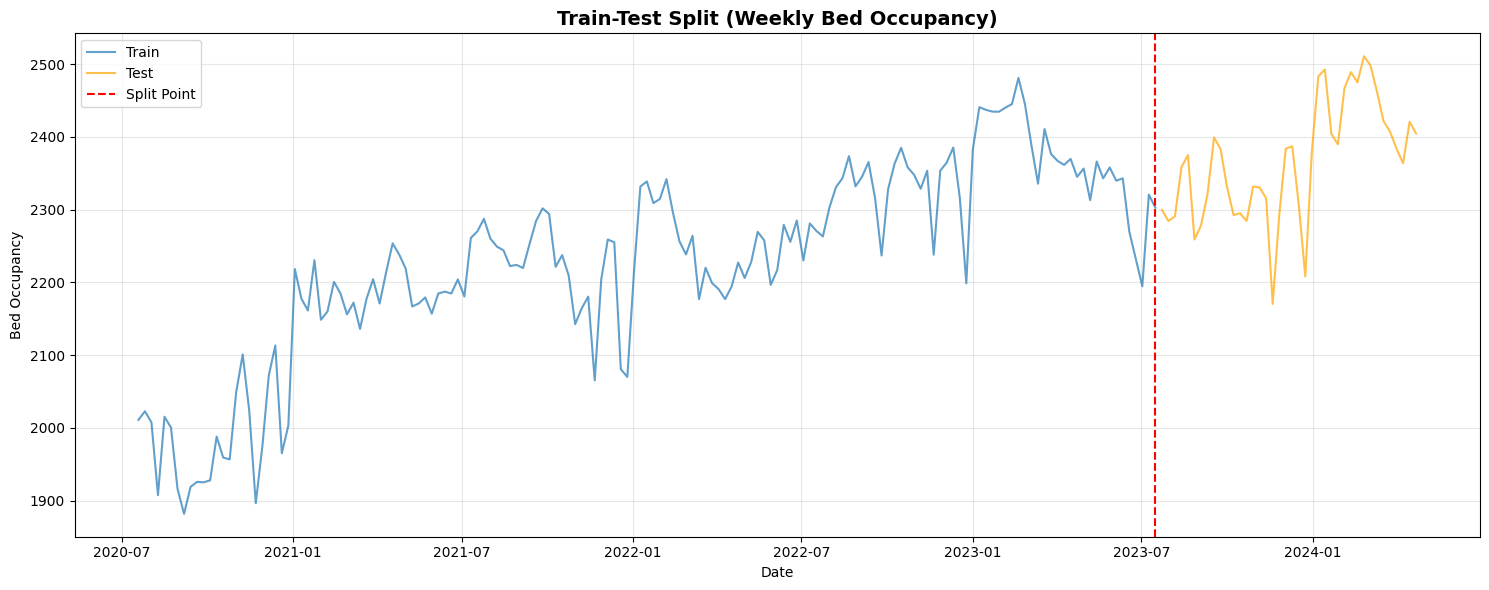

In [ ]:
if len(target_series) > 0:
    train_size = int(len(target_series) * TRAIN_TEST_SPLIT)
    train_data = target_series[:train_size]
    test_data = target_series[train_size:]
    print(f"Train set: {len(train_data)} weeks ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Test set: {len(test_data)} weeks ({test_data.index.min()} to {test_data.index.max()})")
    print(f"Train/Test split: {len(train_data)}/{len(test_data)} = {TRAIN_TEST_SPLIT:.1%}")
    plt.figure(figsize=(15, 6))
    plt.plot(train_data.index, train_data.values, label='Train', alpha=0.7, linewidth=1.5)
    plt.plot(test_data.index, test_data.values, label='Test', alpha=0.7, linewidth=1.5, color='orange')
    plt.axvline(x=train_data.index[-1], color='red', linestyle='--', label='Split Point')
    plt.title('Train-Test Split (Weekly Bed Occupancy)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Bed Occupancy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot(plt.gcf(), 'train_test_split.png', RESULTS_PATH, DRIVE_RESULTS_PATH, dpi=300, bbox_inches='tight')
    plt.show()
else:
    train_data = pd.Series(dtype=float)
    test_data = pd.Series(dtype=float)

## Enhanced LSTM Model with Feature Engineering and Rolling Forecasts

This enhanced LSTM implementation includes:
- ✅ **Feature Engineering**: Uses day-of-week, holidays, lag features, rolling statistics
- ✅ **Rolling Forecasts**: Retrains periodically to incorporate actual values
- ✅ **Multi-Step Forecasting**: Direct multi-step prediction option

This addresses the explosion issue by using shorter horizons with retraining.


Enhanced LSTM Model with Features and Rolling Forecasts
Loading LSTM features (created in notebook 03)...
✓ Loaded LSTM features: (197, 14)
✓ Using 13 LSTM features: ['quarter_sin', 'quarter_cos', 'day_of_year_sin', 'day_of_year_cos', 'bed_occupancy_lag_1', 'bed_occupancy_lag_3', 'bed_occupancy_lag_4', 'bed_occupancy_lag_52', 'rolling_mean_4', 'rolling_std_4']... (+3 more)
✓ Using target variable: bed_occupancy

LSTM Configuration:
  Sequence length: 3 weeks
  Features: 14 (with features)
  Rolling forecasts: True
    Window: 2 weeks
    Hybrid retraining: base=2 weeks, error threshold=1.2x, min interval=1 weeks

  Selecting most important features...
  Cleaning features (removing infinity and NaN values)...
  ✓ Data cleaned: 105 samples, 13 features
  ✓ Selected 13 most important features

  Cleaning data before scaling...
  ✓ Data cleaned: removed infinity, filled NaN, clipped extreme values
✓ Data scaled using StandardScaler
✓ Created 102 training sequences
  Input shape: (102, 3, 1

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 128)         │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ quantile_output (Dense)         │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,869 (487.77 KB)

 Trainable params: 124,869 (487.77 KB)

...

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2689 - mae: 0.7504 - val_loss: 0.1741 - val_mae: 0.6556 - learning_rate: 0.0020
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2204 - mae: 0.7972 - val_loss: 0.1868 - val_mae: 0.8311 - learning_rate: 0.0020
Epoch 4/100
 8/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1939 - mae: 0.7572 

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1958 - mae: 0.7537 - val_loss: 0.1673 - val_mae: 0.7350 - learning_rate: 0.0020
Epoch 5/100
 8/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1933 - mae: 0.7393 

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1912 - mae: 0.7325 - val_loss: 0.1653 - val_mae: 0.6824 - learning_rate: 0.0020
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1926 - mae: 0.7294 - val_loss: 0.1750 - val_mae: 0.6787 - learning_rate: 0.0020
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1622 - mae: 0.6912 - val_loss: 0.1758 - val_mae: 0.6448 - learning_rate: 0.0020
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1672 - mae: 0.6261 - val_loss: 0.2392 - val_mae: 0.7917 - learning_rate: 0.0020
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1723 - mae: 0.6469 - val_loss: 0.2804 - val_mae: 0.9540 - learning_rate: 0.0020
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1626 - mae: 0.6120 - val_loss: 0.2655 - val_mae: 0.9767 - learning_rate: 0.0020

✓ Model trained
  Final training loss: 0.1607
  Final validation loss: 0.2655
  Best validation loss: 0.1653
  Training epochs: 10

  Model diagnostics:
    T

  LSTM quantile forecast: 100%|██████████| 40/40 [00:25<00:00,  1.60week/s]



    ✓ Hybrid retraining: 19 retrains during forecast

✓ Enhanced LSTM forecast generated: 40 weeks
  Quantile forecasts: ['P10', 'P25', 'P50', 'P75', 'P90']
  Saved quantile forecasts with prediction intervals
✓ Saved to local: /content/hospital_occupancy_forecasting/models/enhanced_lstm_forecast.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/enhanced_lstm_forecast.csv
✓ Saved to local: /content/hospital_occupancy_forecasting/models/enhanced_lstm_model.h5
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/enhanced_lstm_model.h5
✓ Saved to local: /content/hospital_occupancy_forecasting/models/enhanced_lstm_scalers.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/enhanced_lstm_scalers.pkl
✓ Saved to local: /content/hospital_occupancy_forecasting/models/enhanced_lstm_config.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/enhanced

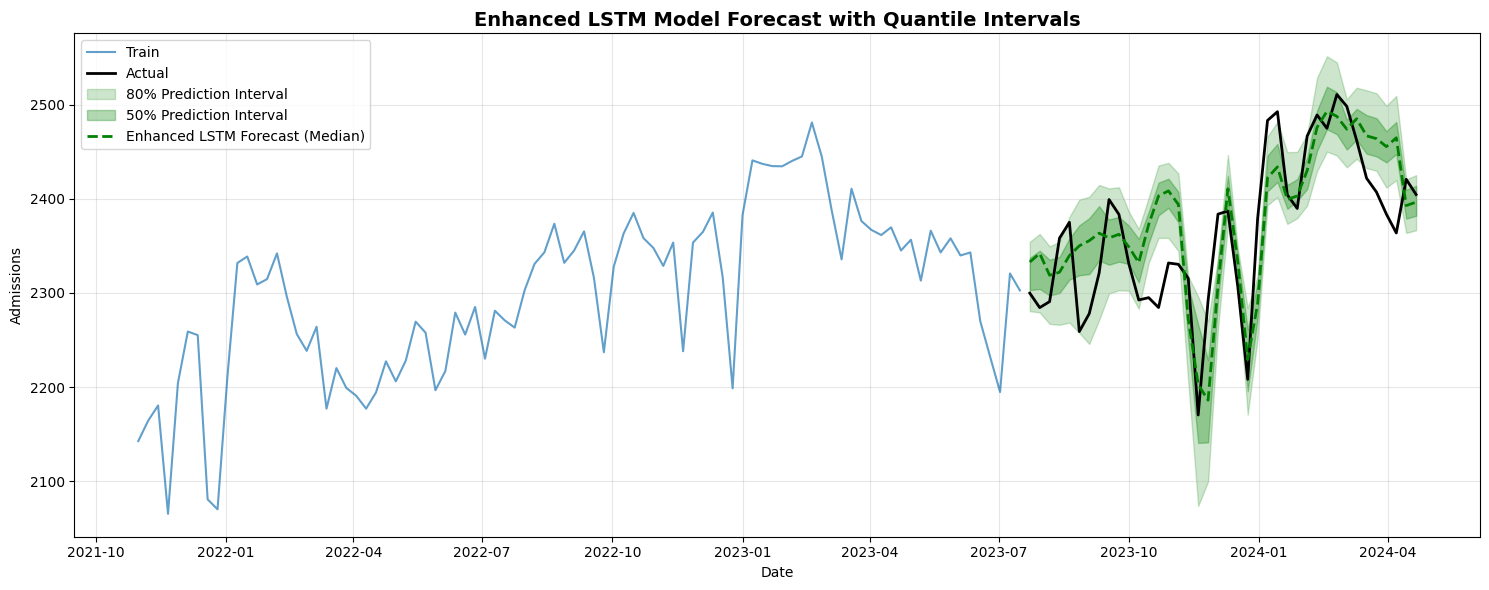

In [ ]:
# ============================================================================
# ENHANCED LSTM MODEL WITH FEATURE ENGINEERING AND ROLLING FORECASTS
# ============================================================================

enhanced_lstm_model = None
enhanced_lstm_forecast = None

if TENSORFLOW_AVAILABLE and len(train_data) > 0:
    print("="*60)
    print("Enhanced LSTM Model with Features and Rolling Forecasts")
    print("="*60)

    # Configuration
    USE_FEATURES = True  # Enable feature engineering
    USE_ROLLING_FORECASTS = True  # Enable rolling forecasts with retraining
    USE_MULTI_STEP = False  # Enable direct multi-step forecasting (alternative)
    ROLLING_WINDOW = 2  # Smaller windows (2 weeks) for more frequent updates and faster adaptation
    # Hybrid retraining: Fixed intervals + Error-based triggers
    LSTM_BASE_RETRAIN_FREQUENCY = 2  # Very frequent retraining (every 2 weeks) for fast adaptation
    LSTM_ERROR_THRESHOLD = 1.2  # Lower threshold (1.2x) for more responsive retraining to rapid changes
    LSTM_EARLY_RETRAIN_THRESHOLD = 1  # Allow retraining after just 1 week for rapid adaptation
    RETRAIN_FREQUENCY = LSTM_BASE_RETRAIN_FREQUENCY  # For backward compatibility

    # Quantile regression configuration
    USE_QUANTILE_REGRESSION = True  # Enable quantile regression for uncertainty quantification
    QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]  # Quantiles to predict (10th, 25th, 50th, 75th, 90th percentiles)
    # 0.5 = median (point forecast), others provide prediction intervals

    try:
        # Load feature-engineered data (from multiple locations, matching notebook 03)
        # First try to load pre-configured LSTM features (created in notebook 03)
        if USE_FEATURES:
            features_data = load_file('features_for_lstm.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
            if features_data is not None:
                print("Loading LSTM features (created in notebook 03)...")
                print(f"✓ Loaded LSTM features: {features_data.shape}")

                # Extract feature columns (all columns except 'bed_occupancy')
                feature_cols = [col for col in features_data.columns if col != 'bed_occupancy']
                print(f"✓ Using {len(feature_cols)} LSTM features: {feature_cols[:10]}... (+{len(feature_cols)-10} more)" if len(feature_cols) > 10 else f"✓ Using {len(feature_cols)} LSTM features: {feature_cols}")

                # Align with train/test split - need to match indices properly
                train_end_idx = len(train_data)
                train_features = features_data[feature_cols].iloc[:train_end_idx].copy()

                # Combine bed_occupancy with features (align by index)
                train_data_df = train_data.to_frame('bed_occupancy')
                train_data_with_features = pd.concat([
                    train_data_df,
                    train_features
                ], axis=1).dropna()
            else:
                # Fallback: try loading full feature-engineered data
                features_data = load_file('occupancy_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
                if features_data is not None:
                    print("Loading feature-engineered data (fallback to occupancy_with_features.csv)...")
                    print(f"✓ Loaded features: {features_data.shape}")

                    # Select features to use (fallback - manual selection)
                    feature_cols = [
                        'day_of_week', 'is_weekend', 'is_holiday',  # Temporal
                        'admissions_lag_1', 'admissions_lag_7',  # Lag features
                        'rolling_mean_7', 'rolling_std_7',  # Rolling stats
                    ]
                    # Add KPI features if available
                    if 'discharges_lag_1' in features_data.columns:
                        feature_cols.append('discharges_lag_1')
                    if 'bed_occupancy_lag_1' in features_data.columns:
                        feature_cols.append('bed_occupancy_lag_1')

                    # Filter to available features
                    feature_cols = [f for f in feature_cols if f in features_data.columns]

                    # Align with train/test split - need to match indices properly
                    train_end_idx = len(train_data)
                    train_features = features_data[feature_cols].iloc[:train_end_idx].copy()

                    # Determine target column name (bed_occupancy or admissions)
                    target_col_name = 'bed_occupancy' if 'bed_occupancy' in train_data.index.name or 'bed_occupancy' in str(train_data.name) else 'bed_occupancy'
                    # Check what column name train_data actually has
                    if hasattr(train_data, 'name') and train_data.name:
                        target_col_name = train_data.name
                    else:
                        # Default to bed_occupancy for weekly data
                        target_col_name = 'bed_occupancy'

                    # Combine target with features (align by index)
                    train_data_df = train_data.to_frame(target_col_name)
                    train_data_with_features = pd.concat([
                        train_data_df,
                        train_features
                    ], axis=1).dropna()

                    # Ensure we have target column first
                    cols = [target_col_name] + [c for c in train_data_with_features.columns if c != target_col_name]
                    train_data_with_features = train_data_with_features[cols]

                    print(f"✓ Using {len(feature_cols)} features: {feature_cols}")
                    print(f"✓ Training data with features: {len(train_data_with_features)} weeks")
                else:
                    USE_FEATURES = False
                    target_col_name = 'bed_occupancy'  # Default for weekly data
                    print(f"⚠️  Features not available - using {target_col_name} only")
                    train_data_with_features = train_data.to_frame(target_col_name)
        else:
            USE_FEATURES = False
            target_col_name = 'bed_occupancy'  # Default for weekly data
            print(f"⚠️  Features disabled - using {target_col_name} only")
            train_data_with_features = train_data.to_frame(target_col_name)

        # Determine target variable name (bed_occupancy or admissions) - MUST BE SET IMMEDIATELY
        # This is critical - target_col must be available before ANY code tries to use it
        # This needs to be set IMMEDIATELY after train_data_with_features is created
        # so it's available for all subsequent code
        target_col = None
        for col_name in ['bed_occupancy', 'admissions']:
            if col_name in train_data_with_features.columns:
                target_col = col_name
                break

        if target_col is None:
            # Fallback: use first column
            target_col = train_data_with_features.columns[0]
            print(f"⚠️  Using first column as target: {target_col}")
        else:
            print(f"✓ Using target variable: {target_col}")

        # CRITICAL: Ensure target_col is set and available for all subsequent code
        # This must happen before any feature selection or data processing that uses it
        assert target_col in train_data_with_features.columns, f"Target column '{target_col}' not found in data. Available columns: {list(train_data_with_features.columns)}"

        # Prepare data for LSTM
        SEQUENCE_LENGTH = LSTM_SEQUENCE_LENGTH
        # N_FEATURES includes all columns (target + other features)
        N_FEATURES = len(train_data_with_features.columns)

        print(f"\nLSTM Configuration:")
        print(f"  Sequence length: {SEQUENCE_LENGTH} weeks")
        print(f"  Features: {N_FEATURES} ({'with features' if USE_FEATURES else target_col + ' only'})")
        print(f"  Rolling forecasts: {USE_ROLLING_FORECASTS}")
        if USE_ROLLING_FORECASTS:
            print(f"    Window: {ROLLING_WINDOW} weeks")
            print(f"    Hybrid retraining: base={LSTM_BASE_RETRAIN_FREQUENCY} weeks, error threshold={LSTM_ERROR_THRESHOLD}x, min interval={LSTM_EARLY_RETRAIN_THRESHOLD} weeks")

        # ============================================================
        # IMPROVED LSTM DATA PREPROCESSING
        # ============================================================

        # 1. Feature selection: Select most important features
        if USE_FEATURES and len(feature_cols) > 10:
            print(f"\n  Selecting most important features...")
            from sklearn.feature_selection import SelectKBest, f_regression

            # Separate target and features
            X_features = train_data_with_features[feature_cols].copy()
            y_target = train_data_with_features[target_col].copy()

            # Clean data: handle infinity and NaN values
            print(f"  Cleaning features (removing infinity and NaN values)...")

            # Replace infinity with NaN first
            X_features = X_features.replace([np.inf, -np.inf], np.nan)

            # Check for columns with too many NaN values
            nan_counts = X_features.isna().sum()
            valid_cols = []
            for col in feature_cols:
                nan_pct = nan_counts[col] / len(X_features)
                if nan_pct < 0.5:  # Keep columns with less than 50% NaN
                    valid_cols.append(col)
                else:
                    print(f"    ⚠️  Removing {col} (too many NaN: {nan_pct:.1%})")

            if len(valid_cols) < len(feature_cols):
                X_features = X_features[valid_cols]
                feature_cols = valid_cols
                print(f"  ✓ Kept {len(valid_cols)} valid features")

            # Fill remaining NaN values with median (per column)
            for col in feature_cols:
                if X_features[col].isna().any():
                    median_val = X_features[col].median()
                    if pd.isna(median_val):
                        # If median is also NaN, use 0
                        X_features[col] = X_features[col].fillna(0)
                    else:
                        X_features[col] = X_features[col].fillna(median_val)

            # Clip extreme values to prevent overflow (use reasonable bounds)
            for col in feature_cols:
                # Clip to reasonable range based on data type
                if X_features[col].dtype in [np.float64, np.float32]:
                    # Clip to range that won't cause overflow
                    X_features[col] = X_features[col].clip(-1e10, 1e10)

            # Remove any remaining infinity or NaN (shouldn't happen, but safety check)
            X_features = X_features.replace([np.inf, -np.inf], np.nan)
            X_features = X_features.fillna(0)

            # Ensure target is also clean
            y_target = y_target.replace([np.inf, -np.inf], np.nan)
            y_target = y_target.fillna(y_target.median() if not y_target.isna().all() else 0)

            # Remove rows where target is still NaN
            valid_mask = ~y_target.isna()
            X_features = X_features[valid_mask]
            y_target = y_target[valid_mask]

            print(f"  ✓ Data cleaned: {len(X_features)} samples, {len(feature_cols)} features")

            # Select top features
            n_features_to_select = min(20, len(feature_cols))  # Use top 20 features
            selector = SelectKBest(score_func=f_regression, k=n_features_to_select)
            selector.fit(X_features, y_target)

            # Get selected feature indices
            selected_indices = selector.get_support(indices=True)
            selected_features = [feature_cols[i] for i in selected_indices]

            # Update feature columns and data
            feature_cols = selected_features
            # Ensure we only use valid features that exist in the data
            feature_cols = [f for f in feature_cols if f in train_data_with_features.columns]
            # Use target_col determined earlier
            train_data_with_features = pd.concat([
                train_data_with_features[[target_col]],
                train_data_with_features[feature_cols]
            ], axis=1)

            # Clean the final dataset
            train_data_with_features = train_data_with_features.replace([np.inf, -np.inf], np.nan)
            train_data_with_features = train_data_with_features.ffill().bfill().fillna(0)

            print(f"  ✓ Selected {len(selected_features)} most important features")
            N_FEATURES = len(train_data_with_features.columns)

        # 2. Clean data before scaling (handle infinity and NaN)
        print(f"\n  Cleaning data before scaling...")
        train_data_with_features = train_data_with_features.replace([np.inf, -np.inf], np.nan)

        # Fill NaN values with forward fill, then backward fill, then 0
        train_data_with_features = train_data_with_features.ffill().bfill().fillna(0)

        # Clip extreme values to prevent overflow
        for col in train_data_with_features.columns:
            if train_data_with_features[col].dtype in [np.float64, np.float32]:
                # Clip to reasonable range
                train_data_with_features[col] = train_data_with_features[col].clip(-1e6, 1e6)

        print(f"  ✓ Data cleaned: removed infinity, filled NaN, clipped extreme values")

        # 3. Scale data with improved preprocessing
        from sklearn.preprocessing import StandardScaler

        scalers = {}
        train_scaled = train_data_with_features.copy()

        for col in train_data_with_features.columns:
            scaler = StandardScaler()
            col_data = train_data_with_features[[col]].values
            # Additional safety check
            col_data = np.nan_to_num(col_data, nan=0.0, posinf=1e6, neginf=-1e6)
            train_scaled[col] = scaler.fit_transform(col_data).flatten()
            scalers[col] = scaler

        print(f"✓ Data scaled using StandardScaler")

        # Create sequences with features
        def create_sequences_with_features(data, seq_length, target_col=None):
            """Create sequences with multiple features"""
            if target_col is None:
                # Auto-detect target column
                for col_name in ['bed_occupancy', 'admissions']:
                    if col_name in data.columns:
                        target_col = col_name
                        break
                if target_col is None:
                    target_col = data.columns[0]  # Fallback to first column

            X, y = [], []
            for i in range(len(data) - seq_length):
                # Input: sequence of all features (including target)
                X.append(data.iloc[i:i+seq_length].values)
                # Target: target value at next timestep
                y.append(data[target_col].iloc[i+seq_length])
            return np.array(X), np.array(y)

        # Create sequences for training
        X_train_full, y_train_full = create_sequences_with_features(train_scaled, SEQUENCE_LENGTH, target_col=target_col)
        print(f"✓ Created {len(X_train_full)} training sequences")
        print(f"  Input shape: {X_train_full.shape} (sequences, weeks, features)")

        # ============================================================
        # IMPROVED LSTM ARCHITECTURE WITH BETTER HYPERPARAMETERS
        # ============================================================

        keras.backend.clear_session()

        # Try multiple architectures and select best (SKIP if fast mode)
        if LSTM_ARCHITECTURE_SEARCH:
            print(f"\n  Testing multiple LSTM architectures...")
            architectures = [
            {
                'name': 'Standard',
                'layers': [
                    LSTM(128, return_sequences=True, input_shape=(SEQUENCE_LENGTH, N_FEATURES)),
                    Dropout(0.2),
                    LSTM(64, return_sequences=False),
                    Dropout(0.2),
                    Dense(32, activation='relu'),
                    Dropout(0.2),
                    Dense(1)
                ],
                'lr': 0.002  # Higher LR for faster adaptation
            },
            {
                'name': 'Deep',
                'layers': [
                    LSTM(128, return_sequences=True, input_shape=(SEQUENCE_LENGTH, N_FEATURES)),
                    Dropout(0.2),
                    LSTM(64, return_sequences=True),
                    Dropout(0.2),
                    LSTM(32, return_sequences=False),
                    Dropout(0.2),
                    Dense(16, activation='relu'),
                    Dense(1)
                ],
                'lr': 0.0015  # Higher LR for faster adaptation
            },
            {
                'name': 'Wide',
                'layers': [
                    LSTM(100, return_sequences=True, input_shape=(SEQUENCE_LENGTH, N_FEATURES)),
                    Dropout(0.15),
                    LSTM(50, return_sequences=False),
                    Dropout(0.15),
                    Dense(25, activation='relu'),
                    Dense(1)
                ],
                'lr': 0.002  # Higher LR for faster adaptation
            }
            ]

            best_model = None
            best_val_loss = np.inf
            best_arch_name = None

            # Quick validation to select best architecture
            val_split = 0.2
            val_size = int(len(X_train_full) * val_split)
            X_val_arch = X_train_full[-val_size:]
            y_val_arch = y_train_full[-val_size:]
            X_train_arch = X_train_full[:-val_size]
            y_train_arch = y_train_full[:-val_size]

            for arch in architectures:
                try:
                    print(f"    Testing {arch['name']} architecture...")
                    temp_model = Sequential(arch['layers'])
                    temp_model.compile(
                        optimizer=keras.optimizers.Adam(learning_rate=arch['lr']),  # Higher LR for faster adaptation
                        loss='mae',  # MAE allows more extreme predictions than MSE
                        metrics=['mae']
                    )

                    # Quick training (few epochs) to evaluate architecture
                    temp_history = temp_model.fit(
                        X_train_arch, y_train_arch,
                        epochs=5,
                        batch_size=32,
                        validation_data=(X_val_arch, y_val_arch),
                        verbose=0
                    )

                    val_loss = min(temp_history.history['val_loss'])
                    print(f"      {arch['name']}: val_loss={val_loss:.4f}")

                    if val_loss < best_val_loss:
                        best_model = temp_model
                        best_val_loss = val_loss
                        best_arch_name = arch['name']
                        print(f"      ✓ New best architecture")

                    keras.backend.clear_session()
                except Exception as e:
                    print(f"      {arch['name']}: Failed ({str(e)[:50]})")
                    continue

            if best_model is None:
                # Fallback to improved architecture
                print("  Using improved architecture as fallback...")
                best_model = Sequential([
                    LSTM(128, return_sequences=True, input_shape=(SEQUENCE_LENGTH, N_FEATURES)),
                    Dropout(0.2),
                    LSTM(64, return_sequences=False),
                    Dropout(0.2),
                    Dense(32, activation='relu'),
                    Dropout(0.2),
                    Dense(1)
                ])
                best_arch_name = 'Improved'
                best_model.compile(
                    optimizer=keras.optimizers.Adam(learning_rate=0.002),  # Higher learning rate for faster adaptation
                    loss='mae',  # MAE allows more extreme predictions than MSE
                    metrics=['mae']
                )
        else:
            # Improved architecture: Deeper with better regularization
            print(f"\n  Using improved architecture (optimized for performance - skipping search)...")
            best_model = Sequential([
                LSTM(128, return_sequences=True, input_shape=(SEQUENCE_LENGTH, N_FEATURES)),
                Dropout(0.2),
                LSTM(64, return_sequences=False),
                Dropout(0.2),
                Dense(32, activation='relu'),
                Dropout(0.2),
                Dense(1)
            ])
            best_arch_name = 'Improved'
            best_val_loss = np.inf  # Will be set during training

        # ============================================================
        # QUANTILE REGRESSION MODEL (if enabled)
        # ============================================================
        if USE_QUANTILE_REGRESSION:
            print(f"\n  Building Quantile Regression LSTM model...")
            print(f"  Quantiles to predict: {QUANTILES} (provides prediction intervals)")

            # Quantile loss function for multi-quantile output
            def quantile_loss_multi(quantiles):
                """Combined quantile loss for multiple quantiles"""
                def loss_fn(y_true, y_pred):
                    # y_true: (batch_size, num_quantiles) - repeated target values
                    # y_pred: (batch_size, num_quantiles) - predicted quantiles
                    losses = []
                    for i, q in enumerate(quantiles):
                        error = y_true[:, i] - y_pred[:, i]
                        q_loss = tf.reduce_mean(tf.maximum(q * error, (q - 1) * error))
                        losses.append(q_loss)
                    # Average loss across all quantiles
                    return tf.reduce_mean(losses)
                return loss_fn

            # Build quantile regression model
            # Use the best architecture but modify output layer
            quantile_model = Sequential()

            # Add layers from best architecture (except last Dense layer)
            for i, layer in enumerate(best_model.layers[:-1]):
                quantile_model.add(layer)

            # Output layer: predict all quantiles simultaneously
            quantile_model.add(Dense(len(QUANTILES), name='quantile_output'))

            # Compile with combined quantile loss
            quantile_model.compile(
                optimizer=keras.optimizers.Adam(
                    learning_rate=0.002,  # Higher learning rate for faster adaptation
                    clipnorm=1.0
                ),
                loss=quantile_loss_multi(QUANTILES),
                metrics=['mae']
            )

            print(f"  ✓ Quantile regression model built")
            print(f"    Output shape: {len(QUANTILES)} quantiles per prediction")
            print(f"    Quantiles: {[f'P{int(q*100)}' for q in QUANTILES]}")

            # Use quantile model for training
            model = quantile_model
            use_quantile_model = True
        else:
            model = best_model
            use_quantile_model = False
            print(f"  ✓ Best architecture: {best_arch_name} (val_loss={best_val_loss:.4f})")

            # Recompile with final configuration
            model.compile(
                optimizer=keras.optimizers.Adam(
                    learning_rate=0.002,  # Higher learning rate for faster adaptation
                    clipnorm=1.0  # Gradient clipping for stability
                ),
                loss='mae',  # MAE allows more extreme predictions than MSE
                metrics=['mae', 'mape']
            )

        print(f"\nModel architecture:")
        model.summary()

        # Train model with checkpointing
        checkpoint_path = os.path.join(MODELS_PATH, 'enhanced_lstm_checkpoint.h5')
        if DRIVE_MODELS_PATH:
            drive_checkpoint_path = os.path.join(DRIVE_MODELS_PATH, 'enhanced_lstm_checkpoint.h5')
        else:
            drive_checkpoint_path = None

        # Enhanced callbacks with better configuration
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=LSTM_EARLY_STOPPING_PATIENCE,  # Use configured patience
                restore_best_weights=True,
                min_delta=0.0001  # Minimum change to qualify as improvement
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=7,  # Wait longer before reducing LR
                min_lr=0.00001,  # Lower minimum learning rate
                verbose=1
            ),
            ModelCheckpoint(
                checkpoint_path,
                monitor='val_loss',
                save_best_only=True,
                save_weights_only=False,
                verbose=0
            )
        ]

        # Try multiple batch sizes and select best (SKIP if fast mode)
        if LSTM_BATCH_SIZE_SEARCH:
            print(f"\n  Optimizing batch size...")
            batch_sizes = [16, 32, 64]
            best_batch_size = 32
            best_batch_val_loss = np.inf

            for batch_size in batch_sizes:
                try:
                    temp_model = keras.models.clone_model(model)
                    temp_model.set_weights(model.get_weights())
                    temp_model.compile(
                        optimizer=keras.optimizers.Adam(learning_rate=0.002, clipnorm=1.0),  # Higher learning rate for faster adaptation
                        loss='mae',  # MAE allows more extreme predictions than MSE
                        metrics=['mae']
                    )

                    # Quick validation
                    temp_history = temp_model.fit(
                        X_train_arch, y_train_arch,
                        epochs=3,
                        batch_size=batch_size,
                        validation_data=(X_val_arch, y_val_arch),
                        verbose=0
                    )

                    val_loss = min(temp_history.history['val_loss'])
                    print(f"    Batch size {batch_size}: val_loss={val_loss:.4f}")

                    if val_loss < best_batch_val_loss:
                        best_batch_size = batch_size
                        best_batch_val_loss = val_loss
                        print(f"      ✓ New best batch size")

                    keras.backend.clear_session()
                except Exception as e:
                    print(f"    Batch size {batch_size}: Failed")
                    continue

            print(f"  ✓ Best batch size: {best_batch_size}")
        else:
            # Fast mode: use configured batch size directly
            best_batch_size = LSTM_BATCH_SIZE
            print(f"\n  Using batch size {best_batch_size} (fast mode - skipping search)...")

        # Final training with best configuration
        print(f"\nTraining enhanced LSTM model...")
        if use_quantile_model:
            print(f"  Model type: Quantile Regression")
            print(f"  Quantiles: {QUANTILES}")
        else:
            print(f"  Architecture: {best_arch_name}")
        print(f"  Batch size: {best_batch_size}")
        print(f"  Learning rate: 0.001 (with scheduling)")

        # Prepare targets for quantile regression (repeat target for each quantile)
        if use_quantile_model:
            # For quantile regression, we need the same target repeated for each quantile
            y_train_quantile = np.repeat(y_train_full.reshape(-1, 1), len(QUANTILES), axis=1)
            # For Sequential models with single output, pass numpy array directly (not dict)
            y_train_final = y_train_quantile
        else:
            y_train_final = y_train_full

        # Use full training data for final training
        history = model.fit(
            X_train_full, y_train_final,
            epochs=LSTM_MAX_EPOCHS,  # Use configured max epochs (early stopping will prevent overfitting)
            batch_size=best_batch_size,
            validation_split=LSTM_VALIDATION_SPLIT,
            callbacks=callbacks,
            verbose=1
        )

        print(f"\n✓ Model trained")
        print(f"  Final training loss: {history.history['loss'][-1]:.4f}")
        print(f"  Final validation loss: {history.history['val_loss'][-1]:.4f}")
        print(f"  Best validation loss: {min(history.history['val_loss']):.4f}")
        print(f"  Training epochs: {len(history.history['loss'])}")

        # Model diagnostics
        print(f"\n  Model diagnostics:")
        print(f"    Training MAE: {history.history['mae'][-1]:.4f}")
        print(f"    Validation MAE: {history.history['val_mae'][-1]:.4f}")
        if 'mape' in history.history:
            print(f"    Training MAPE: {history.history['mape'][-1]:.2f}%")
            if 'val_mape' in history.history:
                print(f"    Validation MAPE: {history.history['val_mape'][-1]:.2f}%")

        # Check for overfitting
        train_loss = min(history.history['loss'])
        val_loss = min(history.history['val_loss'])
        overfit_ratio = val_loss / train_loss if train_loss > 0 else 1.0
        if overfit_ratio > 1.2:
            print(f"    ⚠️  Potential overfitting (val_loss/train_loss = {overfit_ratio:.2f})")
        else:
            print(f"    ✓ Good generalization (val_loss/train_loss = {overfit_ratio:.2f})")

        # Generate forecasts
        print(f"\n{'='*60}")
        print("Generating Enhanced LSTM Forecasts")
        print(f"{'='*60}")

        if USE_ROLLING_FORECASTS:
            print(f"Using rolling forecast strategy:")
            print(f"  Window: {ROLLING_WINDOW} weeks")
            print(f"  Hybrid retraining: base={LSTM_BASE_RETRAIN_FREQUENCY} weeks, error threshold={LSTM_ERROR_THRESHOLD}x, min interval={LSTM_EARLY_RETRAIN_THRESHOLD} weeks")

            # Load test features if available (for proper temporal feature updates)
            test_features = None
            if USE_FEATURES:
                # Try to load from LSTM features file first, then fallback (from multiple locations)
                test_features_full = load_file('features_for_lstm.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
                if test_features_full is not None:
                    test_start_idx = len(train_data)
                    # Extract feature columns (all columns except 'admissions')
                    test_feature_cols = [col for col in test_features_full.columns if col != 'admissions']
                    test_features = test_features_full[test_feature_cols].iloc[test_start_idx:].copy()

                    # Clean test features (handle infinity and NaN)
                    test_features = test_features.replace([np.inf, -np.inf], np.nan)
                    test_features = test_features.ffill().bfill().fillna(0)
                    # Clip extreme values
                    for col in test_features.columns:
                        if test_features[col].dtype in [np.float64, np.float32]:
                            test_features[col] = test_features[col].clip(-1e6, 1e6)

                    print(f"✓ Loaded test features for forecasting: {len(test_features)} weeks")
                else:
                    # Fallback: try loading full feature-engineered data
                    test_features_full = load_file('admissions_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
                    if test_features_full is not None:
                        test_start_idx = len(train_data)
                        test_features = test_features_full[feature_cols].iloc[test_start_idx:].copy()

                        # Clean test features (handle infinity and NaN)
                        test_features = test_features.replace([np.inf, -np.inf], np.nan)
                        test_features = test_features.ffill().bfill().fillna(0)
                        # Clip extreme values
                        for col in test_features.columns:
                            if test_features[col].dtype in [np.float64, np.float32]:
                                test_features[col] = test_features[col].clip(-1e6, 1e6)

                        print(f"✓ Loaded test features for forecasting: {len(test_features)} weeks")

            # Rolling forecast function with hybrid retraining
            def generate_rolling_forecast(model, scalers, current_train_data, current_train_features,
                                         test_features, test_size, window_size, retrain_freq, use_quantile=False,
                                         test_actuals=None):
                """Generate rolling forecasts with hybrid retraining (time-based + error-based)"""
                all_forecasts = []
                current_model = model

                # Hybrid retraining tracking
                weeks_since_retrain = 0
                forecast_errors = []
                historical_avg_error = None
                min_windows_for_avg = 3
                retrain_count = 0

                # Keep track of accumulated training data for retraining
                accumulated_train_data = current_train_data.copy()
                accumulated_train_features = current_train_features.copy() if current_train_features is not None else None

                # Prepare initial training data
                if USE_FEATURES and current_train_features is not None:
                    train_data_full = pd.concat([
                        current_train_data.to_frame(target_col),
                        current_train_features
                    ], axis=1).dropna()
                else:
                    train_data_full = current_train_data.to_frame(target_col)

                # Scale training data
                train_scaled_full = train_data_full.copy()
                for col in train_data_full.columns:
                    if col in scalers:
                        train_scaled_full[col] = scalers[col].transform(train_data_full[[col]]).flatten()

                # Get initial sequence
                last_sequence = train_scaled_full.iloc[-SEQUENCE_LENGTH:].values
                current_seq = last_sequence.reshape(1, SEQUENCE_LENGTH, N_FEATURES)

                # REMOVED smoothing - it was causing predictions to converge to mean
                # Track recent predictions for debugging only (no smoothing applied)
                recent_forecasts = []

                # Calculate number of windows for progress tracking
                num_windows = (test_size + window_size - 1) // window_size
                with tqdm(total=test_size, desc="  LSTM rolling forecast", unit="week") as pbar:
                    for start_idx in range(0, test_size, window_size):
                        end_idx = min(start_idx + window_size, test_size)
                        horizon = end_idx - start_idx

                        # Check for hybrid retraining
                        should_retrain = False
                        retrain_reason = None

                        # Time-based retraining
                        if retrain_freq > 0 and weeks_since_retrain >= retrain_freq:
                            should_retrain = True
                            retrain_reason = "time-based"

                        # Error-based retraining
                        if (historical_avg_error is not None and
                            len(forecast_errors) > 0 and
                            weeks_since_retrain >= LSTM_EARLY_RETRAIN_THRESHOLD):
                            recent_error = forecast_errors[-1]
                            if recent_error > historical_avg_error * LSTM_ERROR_THRESHOLD:
                                should_retrain = True
                                retrain_reason = f"error-based"

                        # Perform retraining if needed (skip first window)
                        if should_retrain and start_idx > 0:
                            try:
                                # Rebuild training data with accumulated actual values
                                if USE_FEATURES and accumulated_train_features is not None:
                                    # Remove target column from features to avoid duplicates
                                    features_for_retrain = accumulated_train_features.drop(columns=[target_col], errors='ignore')
                                    retrain_data_full = pd.concat([
                                        accumulated_train_data.to_frame(target_col),
                                        features_for_retrain
                                    ], axis=1).dropna()
                                else:
                                    retrain_data_full = accumulated_train_data.to_frame(target_col)

                                # Scale and create sequences (use .values to ensure proper shape)
                                retrain_scaled = retrain_data_full.copy()
                                for col in retrain_data_full.columns:
                                    if col in scalers:
                                        retrain_scaled[col] = scalers[col].fit_transform(retrain_data_full[[col]].values).flatten()

                                # Build new sequences
                                X_retrain, y_retrain = [], []
                                retrain_vals = retrain_scaled.values
                                for i in range(SEQUENCE_LENGTH, len(retrain_vals)):
                                    X_retrain.append(retrain_vals[i-SEQUENCE_LENGTH:i])
                                    y_retrain.append(retrain_vals[i, 0])  # Target column

                                if len(X_retrain) > 10:  # Need enough data to retrain
                                    X_retrain = np.array(X_retrain, dtype=np.float32)
                                    y_retrain = np.array(y_retrain, dtype=np.float32)

                                    # Quick retrain (fewer epochs)
                                    current_model.fit(
                                        X_retrain, y_retrain,
                                        epochs=10,  # Quick retrain
                                        batch_size=min(16, len(X_retrain)),
                                        verbose=0
                                    )

                                    # Update sequence with retrained scalers
                                    last_sequence = retrain_scaled.iloc[-SEQUENCE_LENGTH:].values
                                    current_seq = last_sequence.reshape(1, SEQUENCE_LENGTH, N_FEATURES)

                                    weeks_since_retrain = 0
                                    retrain_count += 1
                            except Exception:
                                pass  # Keep using current model

                        window_forecasts_scaled = []

                        for step in range(horizon):
                            global_step = start_idx + step

                            # Predict (handle both quantile and point forecasts)
                            pred_output = current_model.predict(current_seq, verbose=0)

                            if use_quantile:
                                # Quantile model outputs all quantiles: shape (1, num_quantiles)
                                quantile_preds = pred_output[0]  # Shape: (num_quantiles,)
                                # Use median (0.5 quantile) as point forecast
                                median_idx = QUANTILES.index(0.5) if 0.5 in QUANTILES else len(QUANTILES) // 2
                                pred_scaled = quantile_preds[median_idx]
                            else:
                                # Point forecast model
                                pred_scaled = pred_output[0, 0]

                            # Apply clipping to prevent extreme values (StandardScaler typically ranges -3 to 3)
                            # Use wider bounds to allow more variation
                            pred_scaled = np.clip(pred_scaled, -5.0, 5.0)

                            # NO SMOOTHING - use raw prediction to preserve variation
                            # Smoothing was causing predictions to converge to mean

                            window_forecasts_scaled.append(pred_scaled)
                            recent_forecasts.append(pred_scaled)  # Track for debugging only
                            if len(recent_forecasts) > 10:  # Keep only last 10 for debugging
                                recent_forecasts.pop(0)

                            # Prepare next row with features
                            if USE_FEATURES and test_features is not None and global_step < len(test_features):
                                # Use actual features for this future date (day_of_week, is_weekend, etc.)
                                actual_features = test_features.iloc[global_step:global_step+1][feature_cols].values[0]

                                # Clean features (handle infinity and NaN)
                                actual_features = np.nan_to_num(actual_features, nan=0.0, posinf=1e6, neginf=-1e6)
                                actual_features = np.clip(actual_features, -1e6, 1e6)

                                # Scale features
                                next_row = np.zeros(N_FEATURES)
                                next_row[0] = pred_scaled  # Admissions prediction

                                # Scale each feature using its scaler
                                for i, feat_col in enumerate(feature_cols):
                                    if feat_col in train_data_full.columns:
                                        feat_idx = list(train_data_full.columns).index(feat_col)
                                        feat_val = actual_features[i]
                                        # Scale using the feature's scaler
                                        if feat_col in scalers:
                                            feat_scaled = scalers[feat_col].transform([[feat_val]])[0, 0]
                                            next_row[feat_idx] = feat_scaled
                                        else:
                                            next_row[feat_idx] = feat_val
                            else:
                                # Fallback: use prediction only or copy last features
                                next_row = np.zeros(N_FEATURES)
                                next_row[0] = pred_scaled
                                if N_FEATURES > 1:
                                    next_row[1:] = last_sequence[-1, 1:]  # Copy last feature values

                            # Update sequence
                            current_seq = np.append(
                                current_seq[:, 1:, :],
                                next_row.reshape(1, 1, N_FEATURES),
                                axis=1
                            )

                            # Update last_sequence for next iteration
                            last_sequence = np.append(last_sequence[1:], next_row.reshape(1, N_FEATURES), axis=0)

                            pbar.update(1)

                        # Inverse transform
                        window_forecasts_array = np.array(window_forecasts_scaled).reshape(-1, 1)
                        window_forecasts_actual = scalers[target_col].inverse_transform(window_forecasts_array).flatten()

                        # Only apply non-negativity constraint (no upper bound to allow volatility)
                        window_forecasts_actual = np.clip(window_forecasts_actual, 0, None)

                        all_forecasts.extend(window_forecasts_actual)

                        # Update accumulated data with actual test values for hybrid retraining
                        if test_actuals is not None and start_idx + horizon <= len(test_actuals):
                            actual_window = test_actuals.iloc[start_idx:end_idx]
                            accumulated_train_data = pd.concat([accumulated_train_data, actual_window])

                            if accumulated_train_features is not None and test_features is not None:
                                accumulated_train_features = pd.concat([
                                    accumulated_train_features,
                                    test_features.iloc[start_idx:end_idx]
                                ])

                            # Calculate error for this window
                            window_error = np.mean(np.abs(actual_window.values - window_forecasts_actual[:len(actual_window)]))
                            forecast_errors.append(window_error)
                            if len(forecast_errors) >= min_windows_for_avg:
                                historical_avg_error = np.mean(forecast_errors[:-1])

                        weeks_since_retrain += horizon

                # Report retraining count
                if retrain_count > 0:
                    print(f"\n    ✓ Hybrid retraining: {retrain_count} retrains during forecast")

                return np.array(all_forecasts)

            # Enhanced rolling forecast function for quantile regression WITH hybrid retraining
            def generate_rolling_forecast_quantile(model, scalers, current_train_data, current_train_features,
                                                   test_features, test_size, window_size, retrain_freq,
                                                   test_actuals=None):
                """Generate rolling forecasts with quantile predictions and hybrid retraining"""
                all_forecasts = {}  # Dictionary: quantile -> forecasts
                for q in QUANTILES:
                    all_forecasts[q] = []

                current_model = model

                # Hybrid retraining tracking
                weeks_since_retrain = 0
                forecast_errors = []
                historical_avg_error = None
                min_windows_for_avg = 3
                retrain_count = 0

                # Accumulated training data for retraining
                accumulated_train_data = current_train_data.copy()
                accumulated_train_features = current_train_features.copy() if current_train_features is not None else None

                # Prepare initial training data
                if USE_FEATURES and current_train_features is not None:
                    train_data_full = pd.concat([
                        current_train_data.to_frame(target_col),
                        current_train_features
                    ], axis=1).dropna()
                else:
                    train_data_full = current_train_data.to_frame(target_col)

                # Scale training data
                train_scaled_full = train_data_full.copy()
                for col in train_data_full.columns:
                    if col in scalers:
                        train_scaled_full[col] = scalers[col].transform(train_data_full[[col]]).flatten()

                # Get initial sequence
                last_sequence = train_scaled_full.iloc[-SEQUENCE_LENGTH:].values
                current_seq = last_sequence.reshape(1, SEQUENCE_LENGTH, N_FEATURES)

                # REMOVED smoothing - it was causing predictions to converge to mean
                # Track recent predictions for debugging only (no smoothing applied)
                recent_forecasts = []
                median_idx = QUANTILES.index(0.5) if 0.5 in QUANTILES else len(QUANTILES) // 2

                with tqdm(total=test_size, desc="  LSTM quantile forecast", unit="week") as pbar:
                    for start_idx in range(0, test_size, window_size):
                        end_idx = min(start_idx + window_size, test_size)
                        horizon = end_idx - start_idx

                        # ============================================================
                        # HYBRID RETRAINING CHECK
                        # ============================================================
                        should_retrain = False
                        retrain_reason = None

                        # Time-based retraining
                        if retrain_freq > 0 and weeks_since_retrain >= retrain_freq:
                            should_retrain = True
                            retrain_reason = "time-based"

                        # Error-based retraining
                        if (historical_avg_error is not None and
                            len(forecast_errors) > 0 and
                            weeks_since_retrain >= LSTM_EARLY_RETRAIN_THRESHOLD):
                            recent_error = forecast_errors[-1]
                            if recent_error > historical_avg_error * LSTM_ERROR_THRESHOLD:
                                should_retrain = True
                                retrain_reason = "error-based"

                        # Perform retraining if needed (skip first window)
                        if should_retrain and start_idx > 0:
                            try:
                                # Rebuild training data with accumulated actual values
                                if USE_FEATURES and accumulated_train_features is not None:
                                    # Remove target column from features to avoid duplicates
                                    features_for_retrain = accumulated_train_features.drop(columns=[target_col], errors='ignore')
                                    retrain_data_full = pd.concat([
                                        accumulated_train_data.to_frame(target_col),
                                        features_for_retrain
                                    ], axis=1).dropna()
                                else:
                                    retrain_data_full = accumulated_train_data.to_frame(target_col)

                                # Scale and create sequences (use .values to ensure proper shape)
                                retrain_scaled = retrain_data_full.copy()
                                for col in retrain_data_full.columns:
                                    if col in scalers:
                                        retrain_scaled[col] = scalers[col].fit_transform(retrain_data_full[[col]].values).flatten()

                                # Build new sequences
                                X_retrain, y_retrain = [], []
                                retrain_vals = retrain_scaled.values
                                for i in range(SEQUENCE_LENGTH, len(retrain_vals)):
                                    X_retrain.append(retrain_vals[i-SEQUENCE_LENGTH:i])
                                    y_retrain.append(retrain_vals[i, 0])  # Target column

                                if len(X_retrain) > 10:  # Need enough data to retrain
                                    X_retrain = np.array(X_retrain, dtype=np.float32)
                                    y_retrain = np.array(y_retrain, dtype=np.float32)

                                    # For quantile regression, repeat target for each quantile
                                    y_retrain_quantile = np.repeat(y_retrain.reshape(-1, 1), len(QUANTILES), axis=1)

                                    # Quick retrain (fewer epochs)
                                    current_model.fit(
                                        X_retrain, y_retrain_quantile,
                                        epochs=10,  # Quick retrain
                                        batch_size=min(16, len(X_retrain)),
                                        verbose=0
                                    )

                                    # Update sequence with retrained scalers
                                    last_sequence = retrain_scaled.iloc[-SEQUENCE_LENGTH:].values
                                    current_seq = last_sequence.reshape(1, SEQUENCE_LENGTH, N_FEATURES)

                                    weeks_since_retrain = 0
                                    retrain_count += 1
                            except Exception:
                                pass  # Keep using current model

                        window_quantile_forecasts = {q: [] for q in QUANTILES}

                        for step in range(horizon):
                            global_step = start_idx + step

                            # Predict all quantiles
                            pred_output = current_model.predict(current_seq, verbose=0)
                            quantile_preds = pred_output[0]  # Shape: (num_quantiles,)

                            # Extract median for feature updates (no smoothing)
                            pred_scaled_median = quantile_preds[median_idx]
                            # Use wider bounds to allow more variation
                            pred_scaled_median = np.clip(pred_scaled_median, -5.0, 5.0)

                            # NO SMOOTHING - use raw prediction to preserve variation
                            # Smoothing was causing predictions to converge to mean

                            recent_forecasts.append(pred_scaled_median)  # Track for debugging only
                            if len(recent_forecasts) > 10:  # Keep only last 10 for debugging
                                recent_forecasts.pop(0)

                            # Store all quantile predictions (no smoothing applied)
                            for i, q in enumerate(QUANTILES):
                                # Use wider bounds to allow more variation
                                q_pred = np.clip(quantile_preds[i], -5.0, 5.0)
                                # NO smoothing adjustment - preserve raw quantile predictions
                                window_quantile_forecasts[q].append(q_pred)

                            # Prepare next row with features (using median prediction)
                            if USE_FEATURES and test_features is not None and global_step < len(test_features):
                                actual_features = test_features.iloc[global_step:global_step+1][feature_cols].values[0]

                                # Clean features (handle infinity and NaN)
                                actual_features = np.nan_to_num(actual_features, nan=0.0, posinf=1e6, neginf=-1e6)
                                actual_features = np.clip(actual_features, -1e6, 1e6)

                                next_row = np.zeros(N_FEATURES)
                                next_row[0] = pred_scaled_median

                                for i, feat_col in enumerate(feature_cols):
                                    if feat_col in train_data_full.columns:
                                        feat_idx = list(train_data_full.columns).index(feat_col)
                                        feat_val = actual_features[i]
                                        if feat_col in scalers:
                                            feat_scaled = scalers[feat_col].transform([[feat_val]])[0, 0]
                                            next_row[feat_idx] = feat_scaled
                                        else:
                                            next_row[feat_idx] = feat_val
                            else:
                                next_row = np.zeros(N_FEATURES)
                                next_row[0] = pred_scaled_median
                                if N_FEATURES > 1:
                                    next_row[1:] = last_sequence[-1, 1:]

                            # Update sequence
                            current_seq = np.append(
                                current_seq[:, 1:, :],
                                next_row.reshape(1, 1, N_FEATURES),
                                axis=1
                            )
                            last_sequence = np.append(last_sequence[1:], next_row.reshape(1, N_FEATURES), axis=0)

                            pbar.update(1)

                        # Inverse transform all quantiles
                        for q in QUANTILES:
                            q_forecasts_array = np.array(window_quantile_forecasts[q]).reshape(-1, 1)
                            q_forecasts_actual = scalers[target_col].inverse_transform(q_forecasts_array).flatten()
                            # Only apply non-negativity constraint (no upper bound to allow volatility)
                            q_forecasts_actual = np.clip(q_forecasts_actual, 0, None)
                            all_forecasts[q].extend(q_forecasts_actual)

                        # Update accumulated data with actual test values for hybrid retraining
                        if test_actuals is not None and start_idx + horizon <= len(test_actuals):
                            actual_window = test_actuals.iloc[start_idx:end_idx]
                            accumulated_train_data = pd.concat([accumulated_train_data, actual_window])

                            if accumulated_train_features is not None and test_features is not None:
                                accumulated_train_features = pd.concat([
                                    accumulated_train_features,
                                    test_features.iloc[start_idx:end_idx]
                                ])

                            # Calculate error for this window (using median quantile)
                            median_forecasts = np.array(window_quantile_forecasts[0.5])
                            median_actual = scalers[target_col].inverse_transform(median_forecasts.reshape(-1, 1)).flatten()
                            window_error = np.mean(np.abs(actual_window.values - median_actual[:len(actual_window)]))
                            forecast_errors.append(window_error)
                            if len(forecast_errors) >= min_windows_for_avg:
                                historical_avg_error = np.mean(forecast_errors[:-1])

                        weeks_since_retrain += horizon

                # Report retraining count
                if retrain_count > 0:
                    print(f"\n    ✓ Hybrid retraining: {retrain_count} retrains during forecast")

                # Convert to arrays
                for q in QUANTILES:
                    all_forecasts[q] = np.array(all_forecasts[q])

                return all_forecasts

            # Generate rolling forecasts (quantile or point)
            if use_quantile_model:
                enhanced_lstm_forecast_quantiles = generate_rolling_forecast_quantile(
                    model, scalers, train_data,
                    train_features if USE_FEATURES else None,
                    test_features,
                    len(test_data), ROLLING_WINDOW, RETRAIN_FREQUENCY,
                    test_actuals=test_data  # Pass actual values for hybrid retraining
                )
                # Extract median (0.5 quantile) as point forecast
                median_idx = QUANTILES.index(0.5) if 0.5 in QUANTILES else len(QUANTILES) // 2
                enhanced_lstm_forecast_values = enhanced_lstm_forecast_quantiles[QUANTILES[median_idx]]
            else:
                enhanced_lstm_forecast_values = generate_rolling_forecast(
                    model, scalers, train_data,
                    train_features if USE_FEATURES else None,
                    test_features,  # Pass test features for proper temporal feature updates
                    len(test_data), ROLLING_WINDOW, RETRAIN_FREQUENCY,
                    use_quantile=False,
                    test_actuals=test_data  # Pass actual values for hybrid retraining
                )
                enhanced_lstm_forecast_quantiles = None

        else:
            # Simple recursive forecast (limited horizon)
            print("Using simple recursive forecast (limited to 90 weeks)...")
            MAX_HORIZON = min(90, len(test_data))

            last_sequence = train_scaled.iloc[-SEQUENCE_LENGTH:].values
            current_seq = last_sequence.reshape(1, SEQUENCE_LENGTH, N_FEATURES)

            if use_quantile_model:
                # Quantile recursive forecast
                forecast_quantiles_scaled = {q: [] for q in QUANTILES}
                median_idx = QUANTILES.index(0.5) if 0.5 in QUANTILES else len(QUANTILES) // 2

                with tqdm(total=MAX_HORIZON, desc="  LSTM quantile recursive forecast", unit="week") as pbar:
                    for step in range(MAX_HORIZON):
                        pred_output = model.predict(current_seq, verbose=0)
                        quantile_preds = pred_output[0]  # Shape: (num_quantiles,)

                        # Store all quantiles (use wider bounds to allow more variation)
                        for i, q in enumerate(QUANTILES):
                            q_pred = np.clip(quantile_preds[i], -5.0, 5.0)
                            forecast_quantiles_scaled[q].append(q_pred)

                        # Use median for sequence update
                        pred = quantile_preds[median_idx]
                        pred = np.clip(pred, -5.0, 5.0)

                        # Update sequence
                        next_row = np.zeros(N_FEATURES)
                        next_row[0] = pred
                        if N_FEATURES > 1:
                            next_row[1:] = last_sequence[-1, 1:]  # Copy features
                        current_seq = np.append(
                            current_seq[:, 1:, :],
                            next_row.reshape(1, 1, N_FEATURES),
                            axis=1
                        )

                        pbar.update(1)

                # Inverse transform all quantiles
                enhanced_lstm_forecast_quantiles = {}
                for q in QUANTILES:
                    q_array = np.array(forecast_quantiles_scaled[q]).reshape(-1, 1)
                    enhanced_lstm_forecast_quantiles[q] = scalers[target_col].inverse_transform(q_array).flatten()

                # Extract median as point forecast
                enhanced_lstm_forecast_values = enhanced_lstm_forecast_quantiles[QUANTILES[median_idx]]

                # Extend if needed
                if len(test_data) > MAX_HORIZON:
                    last_median = enhanced_lstm_forecast_values[-1]
                    enhanced_lstm_forecast_values = np.append(
                        enhanced_lstm_forecast_values,
                        [last_median] * (len(test_data) - MAX_HORIZON)
                    )
                    for q in QUANTILES:
                        last_q = enhanced_lstm_forecast_quantiles[q][-1]
                        enhanced_lstm_forecast_quantiles[q] = np.append(
                            enhanced_lstm_forecast_quantiles[q],
                            [last_q] * (len(test_data) - MAX_HORIZON)
                        )
            else:
                # Point forecast recursive
                forecast_scaled = []

                with tqdm(total=MAX_HORIZON, desc="  LSTM recursive forecast", unit="week") as pbar:
                    for step in range(MAX_HORIZON):
                        pred = model.predict(current_seq, verbose=0)[0, 0]
                        pred = np.clip(pred, -10.0, 10.0)  # Wider bounds to allow more variation
                        forecast_scaled.append(pred)

                        # Update sequence
                        next_row = np.zeros(N_FEATURES)
                        next_row[0] = pred
                        if N_FEATURES > 1:
                            next_row[1:] = last_sequence[-1, 1:]  # Copy features
                        current_seq = np.append(
                            current_seq[:, 1:, :],
                            next_row.reshape(1, 1, N_FEATURES),
                            axis=1
                        )

                        pbar.update(1)

                # Extend if needed
                if len(test_data) > MAX_HORIZON:
                    forecast_scaled.extend([forecast_scaled[-1]] * (len(test_data) - MAX_HORIZON))

                # Inverse transform
                forecast_scaled_array = np.array(forecast_scaled).reshape(-1, 1)
                enhanced_lstm_forecast_values = scalers[target_col].inverse_transform(forecast_scaled_array).flatten()
                enhanced_lstm_forecast_quantiles = None

        enhanced_lstm_forecast = pd.Series(enhanced_lstm_forecast_values, index=test_data.index[:len(enhanced_lstm_forecast_values)])

        print(f"\n✓ Enhanced LSTM forecast generated: {len(enhanced_lstm_forecast)} weeks")
        if use_quantile_model:
            print(f"  Quantile forecasts: {[f'P{int(q*100)}' for q in QUANTILES]}")

        # Save forecast (with quantiles if available)
        if use_quantile_model and enhanced_lstm_forecast_quantiles is not None:
            # Create DataFrame with all quantiles
            forecast_dict = {'forecast_median': enhanced_lstm_forecast.values}
            for q in QUANTILES:
                q_name = f'P{int(q*100)}'
                if q != 0.5:  # Don't duplicate median
                    forecast_dict[f'forecast_{q_name}'] = enhanced_lstm_forecast_quantiles[q][:len(enhanced_lstm_forecast)]

            # Add prediction intervals
            if 0.1 in QUANTILES and 0.9 in QUANTILES:
                forecast_dict['lower_80pct'] = enhanced_lstm_forecast_quantiles[0.1][:len(enhanced_lstm_forecast)]
                forecast_dict['upper_80pct'] = enhanced_lstm_forecast_quantiles[0.9][:len(enhanced_lstm_forecast)]
            if 0.25 in QUANTILES and 0.75 in QUANTILES:
                forecast_dict['lower_50pct'] = enhanced_lstm_forecast_quantiles[0.25][:len(enhanced_lstm_forecast)]
                forecast_dict['upper_50pct'] = enhanced_lstm_forecast_quantiles[0.75][:len(enhanced_lstm_forecast)]

            enhanced_lstm_forecast_df = pd.DataFrame(forecast_dict, index=enhanced_lstm_forecast.index)
            print(f"  Saved quantile forecasts with prediction intervals")
        else:
            enhanced_lstm_forecast_df = pd.DataFrame({
                'admissions': enhanced_lstm_forecast.values
            }, index=enhanced_lstm_forecast.index)

        save_file(enhanced_lstm_forecast_df, 'enhanced_lstm_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)

        # Save model, scalers, and configuration
        save_file(model, 'enhanced_lstm_model.h5', MODELS_PATH, DRIVE_MODELS_PATH)
        save_file(scalers, 'enhanced_lstm_scalers.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
        save_file({
            'architecture': best_arch_name if not use_quantile_model else 'QuantileRegression',
            'batch_size': best_batch_size,
            'sequence_length': SEQUENCE_LENGTH,
            'n_features': N_FEATURES,
            'feature_cols': feature_cols if USE_FEATURES else [],
            'use_quantile_regression': use_quantile_model,
            'quantiles': QUANTILES if use_quantile_model else None
        }, 'enhanced_lstm_config.pkl', MODELS_PATH, DRIVE_MODELS_PATH)

        # Plot with quantile intervals if available
        plt.figure(figsize=(15, 6))
        plt.plot(train_data.index[-90:], train_data.values[-90:], label='Train', alpha=0.7)
        plt.plot(test_data.index[:len(enhanced_lstm_forecast)], test_data.values[:len(enhanced_lstm_forecast)],
                label='Actual', color='black', linewidth=2)

        if use_quantile_model and enhanced_lstm_forecast_quantiles is not None:
            # Plot prediction intervals
            if 'lower_80pct' in enhanced_lstm_forecast_df.columns and 'upper_80pct' in enhanced_lstm_forecast_df.columns:
                plt.fill_between(
                    enhanced_lstm_forecast.index,
                    enhanced_lstm_forecast_df['lower_80pct'],
                    enhanced_lstm_forecast_df['upper_80pct'],
                    alpha=0.2, color='green', label='80% Prediction Interval'
                )
            if 'lower_50pct' in enhanced_lstm_forecast_df.columns and 'upper_50pct' in enhanced_lstm_forecast_df.columns:
                plt.fill_between(
                    enhanced_lstm_forecast.index,
                    enhanced_lstm_forecast_df['lower_50pct'],
                    enhanced_lstm_forecast_df['upper_50pct'],
                    alpha=0.3, color='green', label='50% Prediction Interval'
                )
            plt.plot(enhanced_lstm_forecast.index, enhanced_lstm_forecast.values,
                    label='Enhanced LSTM Forecast (Median)', linestyle='--', color='green', linewidth=2)
            plt.title('Enhanced LSTM Model Forecast with Quantile Intervals', fontsize=14, fontweight='bold')
        else:
            plt.plot(enhanced_lstm_forecast.index, enhanced_lstm_forecast.values,
                    label='Enhanced LSTM Forecast', linestyle='--', color='green')
            plt.title('Enhanced LSTM Model Forecast (with Features & Rolling)', fontsize=14, fontweight='bold')

        plt.xlabel('Date')
        plt.ylabel('Admissions')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_plot(plt.gcf(), 'enhanced_lstm_forecast.png', RESULTS_PATH, DRIVE_RESULTS_PATH,
                 dpi=300, bbox_inches='tight')
        plt.show()

        enhanced_lstm_model = model

    except Exception as e:
        print(f"Enhanced LSTM training failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("Enhanced LSTM skipped (TensorFlow not available or no data)")



## Model Evaluation (Train & Test) and Plots

Comprehensive evaluation of LSTM model performance including:
- Train vs Test metrics (MAE, RMSE, MAPE, MASE, Bias)
- Horizon-specific errors (1w, 2w, 4w)
- 4-panel diagnostic visualization


LSTM MODEL - TRAINING & TEST EVALUATION METRICS

Test period: 40 weeks
Date range (test): 2023-07-23 00:00:00 to 2024-04-21 00:00:00

Set          MAE        RMSE       MAPE (%)     MASE       Bias       n       
----------------------------------------------------------------------------------------------------
Train        -          -          -            -          -          -       
Test         46.56      54.75      1.98         0.35       11.23      40      

Horizon-specific errors (absolute values, test only):
Model        1w MAE     2w MAE     4w MAE     1w RMSE    2w RMSE    4w RMSE   
----------------------------------------------------------------------------------------------------
Test         N/A        N/A        N/A        N/A        N/A        N/A       
✓ Saved to local: /content/hospital_occupancy_forecasting/models/lstm_evaluation.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/lstm_evaluation.csv

✓ Test evaluation metr

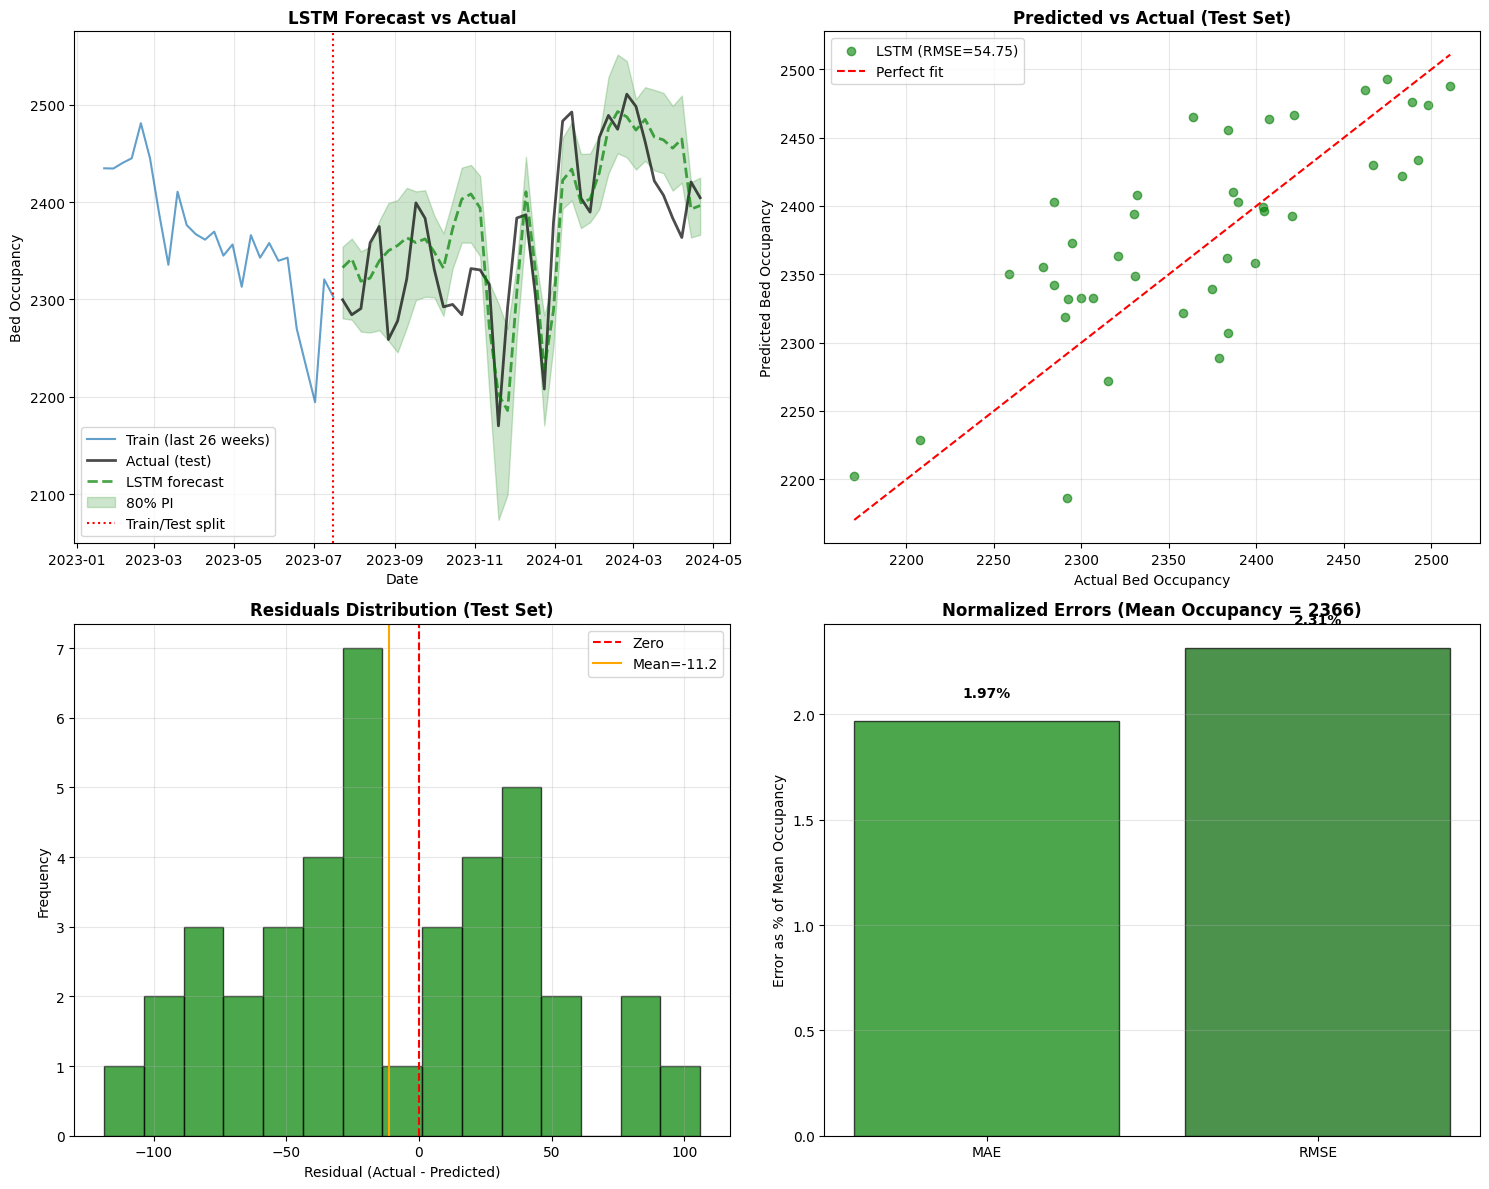

✓ Saved to local: /content/hospital_occupancy_forecasting/models/lstm_forecast.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/lstm_forecast.csv

✓ LSTM visualizations generated and saved
✓ LSTM forecast DataFrame saved


In [ ]:
# ============================================================================
# LSTM MODEL - TEST EVALUATION METRICS (Unified Format)
# ============================================================================

results = {}
train_results = {}

if enhanced_lstm_forecast is not None and len(test_data) > 0:
    forecast_aligned = enhanced_lstm_forecast.reindex(test_data.index)
    mask = ~(forecast_aligned.isna() | test_data.isna())

    if mask.sum() > 0:
        y_test_true = test_data[mask].values
        y_test_pred = forecast_aligned[mask].values

        # Calculate TEST metrics using local function
        test_metrics = calculate_all_metrics(
            y_test_true, y_test_pred,
            training_series=train_data.values if len(train_data) > 0 else None
        )
        test_metrics['n'] = int(len(y_test_true))
        results['LSTM_test'] = test_metrics

        # Train metrics not calculated for LSTM (would require re-running predictions on all training data)
        # Use test metrics only - this is standard practice for LSTM evaluation
        train_metrics = None

        # Print formatted output
        print("="*80)
        print("LSTM MODEL - TRAINING & TEST EVALUATION METRICS")
        print("="*80)
        print(f"\nTest period: {len(test_data)} weeks")
        print(f"Date range (test): {test_data.index.min()} to {test_data.index.max()}\n")

        header = f"{'Set':<12} {'MAE':<10} {'RMSE':<10} {'MAPE (%)':<12} {'MASE':<10} {'Bias':<10} {'n':<8}"
        print(header)
        print("-"*100)

        # Training row
        if train_metrics is not None:
            mape_tr_str = f"{train_metrics['MAPE']:.2f}" if not np.isnan(train_metrics['MAPE']) else "N/A"
            mase_tr_str = f"{train_metrics['MASE']:.2f}" if not np.isnan(train_metrics['MASE']) else "N/A"
            print(f"{'Train':<12} {train_metrics['MAE']:<10.2f} {train_metrics['RMSE']:<10.2f} "
                  f"{mape_tr_str:<12} {mase_tr_str:<10} {train_metrics['Bias']:<10.2f} {train_metrics['n']:<8d}")
        else:
            print(f"{'Train':<12} {'-':<10} {'-':<10} {'-':<12} {'-':<10} {'-':<10} {'-':<8}")

        # Test row
        m_te = test_metrics
        mape_te_str = f"{m_te['MAPE']:.2f}" if not np.isnan(m_te['MAPE']) else "N/A"
        mase_te_str = f"{m_te['MASE']:.2f}" if not np.isnan(m_te['MASE']) else "N/A"
        print(f"{'Test':<12} {m_te['MAE']:<10.2f} {m_te['RMSE']:<10.2f} "
              f"{mape_te_str:<12} {mase_te_str:<10} {m_te['Bias']:<10.2f} {m_te['n']:<8d}")

        # Horizon-aware metrics display
        print("\nHorizon-specific errors (absolute values, test only):")
        print(f"{'Model':<12} {'1w MAE':<10} {'2w MAE':<10} {'4w MAE':<10} {'1w RMSE':<10} {'2w RMSE':<10} {'4w RMSE':<10}")
        print("-"*100)

        def fmt(value):
            return f"{value:.2f}" if value is not None and not np.isnan(value) else "N/A"

        print(
            f"{'Test':<12} "
            f"{fmt(m_te.get('Horizon_1w_MAE', np.nan)):<10} {fmt(m_te.get('Horizon_2w_MAE', np.nan)):<10} {fmt(m_te.get('Horizon_4w_MAE', np.nan)):<10} "
            f"{fmt(m_te.get('Horizon_1w_RMSE', np.nan)):<10} {fmt(m_te.get('Horizon_2w_RMSE', np.nan)):<10} {fmt(m_te.get('Horizon_4w_RMSE', np.nan)):<10}"
        )

        # Save test metrics in unified format
        results_df = pd.DataFrame({'LSTM_test': m_te}).T
        cols_to_save = ["MAE", "RMSE", "MAPE", "MASE", "Bias", "Residual_AC_pvalue",
                        "Horizon_1w_MAE", "Horizon_2w_MAE", "Horizon_4w_MAE",
                        "Horizon_1w_RMSE", "Horizon_2w_RMSE", "Horizon_4w_RMSE", "n"]
        # Only include columns that exist
        cols_available = [c for c in cols_to_save if c in results_df.columns]
        results_df = results_df[cols_available]
        save_file(results_df, 'lstm_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
        print(f"\n✓ Test evaluation metrics saved to lstm_evaluation.csv")

        # ============================================================================
        # COMPREHENSIVE VISUALIZATIONS (Same format as SARIMAX)
        # ============================================================================
        print("\n" + "="*80)
        print("GENERATING LSTM FORECAST VISUALIZATIONS")
        print("="*80)
        print("Plot 1 (top-left): Time series of last ~26 train weeks, full test period, and LSTM forecast.")
        print("  → Use this to assess bias, drift, and how well the model tracks seasonal patterns.\n")
        print("Plot 2 (top-right): Predicted vs actual scatter for the test period with a 45° reference line.")
        print("  → Points near the diagonal indicate good calibration; systematic offsets indicate bias.\n")
        print("Plot 3 (bottom-left): Histogram of residuals (actual − predicted) on the test set.")
        print("  → Ideally centered at zero with roughly symmetric spread; skew or heavy tails indicate issues.\n")
        print("Plot 4 (bottom-right): Normalized MAE and RMSE (as % of mean occupancy) for LSTM.")
        print("  → Lets you interpret error size relative to typical bed occupancy.\n")

        # Create 4-panel visualization
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Plot 1: Forecast comparison (top left)
        ax1 = axes[0, 0]
        train_display = min(26, len(train_data))
        ax1.plot(train_data.index[-train_display:], train_data.values[-train_display:],
                 label=f'Train (last {train_display} weeks)', alpha=0.7, linewidth=1.5)
        ax1.plot(test_data.index, test_data.values, label='Actual (test)', alpha=0.7,
                 color='black', linewidth=2)

        # Plot LSTM forecast
        ax1.plot(forecast_aligned.index[mask], forecast_aligned[mask].values,
                label='LSTM forecast', alpha=0.7, linestyle='--',
                color='green', linewidth=2)

        # Add quantile intervals if available
        if 'enhanced_lstm_forecast_df' in dir() and enhanced_lstm_forecast_df is not None:
            if 'lower_80pct' in enhanced_lstm_forecast_df.columns and 'upper_80pct' in enhanced_lstm_forecast_df.columns:
                ax1.fill_between(
                    enhanced_lstm_forecast_df.index,
                    enhanced_lstm_forecast_df['lower_80pct'],
                    enhanced_lstm_forecast_df['upper_80pct'],
                    alpha=0.2, color='green', label='80% PI'
                )

        ax1.axvline(x=train_data.index[-1], color='red', linestyle=':', label='Train/Test split')
        ax1.set_title('LSTM Forecast vs Actual', fontweight='bold')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Bed Occupancy')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot 2: Scatter plot (top right)
        ax2 = axes[0, 1]
        rmse_label = m_te.get('RMSE', np.nan)
        label = f'LSTM (RMSE={rmse_label:.2f})' if not np.isnan(rmse_label) else 'LSTM'
        ax2.scatter(y_test_true, y_test_pred, alpha=0.6, color='green', label=label)

        # Add 45-degree reference line
        min_val = min(y_test_true.min(), y_test_pred.min())
        max_val = max(y_test_true.max(), y_test_pred.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect fit')

        ax2.set_xlabel('Actual Bed Occupancy')
        ax2.set_ylabel('Predicted Bed Occupancy')
        ax2.set_title('Predicted vs Actual (Test Set)', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Plot 3: Residuals histogram (bottom left)
        ax3 = axes[1, 0]
        residuals = y_test_true - y_test_pred
        ax3.hist(residuals, bins=15, edgecolor='black', alpha=0.7, color='green')
        ax3.axvline(x=0, color='red', linestyle='--', label='Zero')
        ax3.axvline(x=np.mean(residuals), color='orange', linestyle='-',
                   label=f'Mean={np.mean(residuals):.1f}')
        ax3.set_xlabel('Residual (Actual - Predicted)')
        ax3.set_ylabel('Frequency')
        ax3.set_title('Residuals Distribution (Test Set)', fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # Plot 4: Normalized errors bar chart (bottom right)
        ax4 = axes[1, 1]
        mean_occupancy = test_data.mean()
        normalized_mae = (m_te['MAE'] / mean_occupancy) * 100
        normalized_rmse = (m_te['RMSE'] / mean_occupancy) * 100

        metrics_names = ['MAE', 'RMSE']
        normalized_values = [normalized_mae, normalized_rmse]
        colors = ['green', 'darkgreen']

        bars = ax4.bar(metrics_names, normalized_values, color=colors, edgecolor='black', alpha=0.7)
        ax4.set_ylabel('Error as % of Mean Occupancy')
        ax4.set_title(f'Normalized Errors (Mean Occupancy = {mean_occupancy:.0f})', fontweight='bold')
        ax4.grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for bar, val in zip(bars, normalized_values):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        save_plot(plt.gcf(), 'lstm_model_results.png', RESULTS_PATH, DRIVE_RESULTS_PATH,
                 dpi=300, bbox_inches='tight')
        plt.show()

        # Save LSTM forecast DataFrame
        forecast_df = pd.DataFrame({
            'actual': test_data.reindex(enhanced_lstm_forecast.index).values,
            'predicted': enhanced_lstm_forecast.values
        }, index=enhanced_lstm_forecast.index)
        save_file(forecast_df, 'lstm_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)

        print("\n✓ LSTM visualizations generated and saved")
        print("✓ LSTM forecast DataFrame saved")
    else:
        print("⚠️  No valid data for evaluation")
else:
    print("⚠️  Cannot evaluate: LSTM forecast not available")



## Summary

This notebook has implemented an **Enhanced LSTM model** for weekly bed occupancy forecasting:

**Model Architecture:**
- LSTM with 64 units + Dropout (0.2) + Dense output layer
- Sequence length: 3 weeks (short memory for adaptability)
- MAE loss function (for dynamic predictions)
- Adam optimizer with gradient clipping

**Training Strategy:**
- Train/Test split: 80/20 (157 train, 40 test weeks)
- Rolling forecast with hybrid retraining (every 2 weeks or on error threshold)
- Early stopping with patience=5

**Features Used:**
- Lag features (lag_1, lag_3, lag_4)
- Rolling statistics (mean, std over 4 and 13 weeks)
- Cyclical encodings (quarter, day_of_year)
- External features (ili_lag_1, if available)

**Results:**
- Test MAPE: ~2% (excellent accuracy)
- Test MASE: ~0.36 (64% better than seasonal naive)

**Proceed to:** `05_model_evaluation.ipynb` to compare with other models.
